In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
import mapclassify as mc
from shapely.geometry import box

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
AZUL, ROJO, GRIS = "#1F3864", "#9C0006", "#7F7F7F"

# 1. Del punto a la entidad espacial

In [2]:
deptos = gpd.read_file("ourdata/ColombiaDepartments.json")

In [3]:
deptos

,source,id,name,geometry
0,https://simplemaps.com,CONAR,Nariño,"MULTIPOLYGON (((-78.0739 2.64682, -77.98392 2...."
1,https://simplemaps.com,COPUT,Putumayo,"POLYGON ((-77.10386 0.35414, -77.10188 0.3607,..."
2,https://simplemaps.com,COCHO,Chocó,"MULTIPOLYGON (((-76.98546 8.25618, -76.98426 8..."
3,https://simplemaps.com,COGUA,Guainía,"POLYGON ((-69.84118 1.70758, -69.84155 1.7078,..."
4,https://simplemaps.com,COVAU,Vaupés,"POLYGON ((-70.10497 2.10116, -70.1083 2.05879,..."
5,https://simplemaps.com,COAMA,Amazonas,"POLYGON ((-74.41472 -0.56376, -73.86414 -0.392..."
6,https://simplemaps.com,COLAG,La Guajira,"POLYGON ((-72.91523 10.42817, -72.91588 10.428..."
7,https://simplemaps.com,COCES,Cesar,"POLYGON ((-73.60579 10.84551, -73.45215 10.866..."
8,https://simplemaps.com,CONSA,Norte de Santander,"POLYGON ((-73.62545 7.73454, -73.64033 7.74516..."
9,https://simplemaps.com,COARA,Arauca,"POLYGON ((-71.96402 7.00592, -71.88101 6.9866,..."


In [4]:
deptos.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [172]:
url_estaciones = 'https://raw.githubusercontent.com/S4GC/Geopositioning-and-Navigation/refs/heads/master/ourdata/Cat%C3%A1logo_Nacional_de_Estaciones_del_IDEAM_20260822.csv'

In [174]:
#h = pd.read_csv("ourdata/Catálogo_Nacional_de_Estaciones_del_IDEAM_20260822.csv")#,
h = pd.read_csv(url_estaciones)

In [6]:
eventos = h.drop_duplicates() 

In [7]:
eventos

,Codigo,Nombre,Categoria,Tecnologia,Estado,Departamento,Municipio,Ubicación,Altitud,LONGITUD,LATITUD,Fecha_instalacion,Fecha_suspension,Area Operativa,Corriente,Area Hidrografica,Zona Hidrografica,Subzona hidrografica,Entidad
0,24030700,COVARACHIA [24030700],Pluviométrica,Convencional,Activa,Boyacá,Covarachía,"(-72.739228889, 6.500608056)","2,244",-72.739229,6.500608,15/06/1974,NaN,Area Operativa 06 - Boyacá-Casanare-Vichada,NaN,Magdalena Cauca,Sogamoso,Río Chicamocha,INSTITUTO DE HIDROLOGÍA METEOROLOGÍA Y ESTUDIO...
1,35075040,INSTITUCION AGRICOLA MACANAL [35075040],Climatológica Principal,Convencional,Activa,Boyacá,Macanal,"(-73.316151944, 4.974416111)","1,742",-73.316152,4.974416,15/07/1982,NaN,Area Operativa 06 - Boyacá-Casanare-Vichada,NaN,Orinoco,Meta,Río Garagoa,INSTITUTO DE HIDROLOGÍA METEOROLOGÍA Y ESTUDIO...
2,35070170,NAZARETH [35070170],Pluviométrica,Convencional,Activa,Boyacá,Santa María,"(-73.219595, 4.735228889)",439,-73.219595,4.735229,15/09/1972,NaN,Area Operativa 06 - Boyacá-Casanare-Vichada,NaN,Orinoco,Meta,Río Guavio,INSTITUTO DE HIDROLOGÍA METEOROLOGÍA Y ESTUDIO...
3,35190030,CHAMEZA [35190030],Pluviográfica,Convencional,Activa,Casanare,Chámeza,"(-72.871813889, 5.215341944)","1,129",-72.871814,5.215342,15/11/1974,NaN,Area Operativa 06 - Boyacá-Casanare-Vichada,NaN,Orinoco,Meta,Río Cusiana,INSTITUTO DE HIDROLOGÍA METEOROLOGÍA Y ESTUDIO...
4,35060220,LA GLORIA [35060220],Pluviométrica,Convencional,Activa,Cundinamarca,Ubalá,"(-73.41977778, 4.815694444)","1,845",-73.419778,4.815694,15/09/1964,NaN,Area Operativa 11 - Cundinamarca-Amazonas,NaN,Orinoco,Meta,Río Guavio,INSTITUTO DE HIDROLOGÍA METEOROLOGÍA Y ESTUDIO...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9722,2909500641,I.E. FUNDACIÓN PIES DESCALZOS - AUT [2909500641],Climatológica Ordinaria,Automática con Telemetría,Activa,Atlantico,Barranquilla,"(-74.86841, 11.02853)",19,-74.868410,11.028530,01/10/2025,NaN,Area Operativa 02 - Atlántico-Bolivar-Sucre,NaN,Magdalena Cauca,Bajo Magdalena,Cienaga Mallorquin,CRUZ ROJA COLOMBIANA
9723,35160000,LAS CINTAS [35160000],Pluviométrica,Automática con Telemetría,Suspendida,Boyacá,Sogamoso,"(-72.86747222, 5.614277778)","3,400",-72.867472,5.614278,31/12/2016,29/05/2026,Area Operativa 06 - Boyacá-Casanare-Vichada,NaN,Orinoco,Meta,Lago de Tota,INSTITUTO DE HIDROLOGÍA METEOROLOGÍA Y ESTUDIO...
9724,2405500643,EL PLACER - AUT [2405500643],Climatológica Principal,Automática con Telemetría,Activa,Santander,Betulia,"(-73.303957778, 7.003903056)",940,-73.303958,7.003903,11/02/2012,NaN,Area Operativa 08 - Santanderes-Arauca,NaN,Magdalena Cauca,Sogamoso,Río Sogamoso,ISAGEN S.A. E.S.P
9725,26210070,CAICEDO [26210070],Pluviométrica,Convencional,Activa,Antioquia,Caicedo,"(-75.99825, 6.4168806)","2,005",-75.998250,6.416881,15/10/1970,NaN,Area Operativa 01 - Antioquia-Chocó,NaN,Magdalena Cauca,Cauca,Directos Río Cauca entre Río San Juan y Pto Va...,INSTITUTO DE HIDROLOGÍA METEOROLOGÍA Y ESTUDIO...


In [8]:
deptos.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
estaciones = gpd.GeoDataFrame(eventos, geometry=gpd.points_from_xy(eventos.LONGITUD, eventos.LATITUD), crs=4326).to_crs(deptos.crs)estaciones = gpd.GeoDataFrame(eventos, geometry=gpd.points_from_xy(eventos.LONGITUD, eventos.LATITUD), crs=4326).to_crs(deptos.crs)

In [10]:
estaciones = estaciones[estaciones.within(deptos.union_all())]

In [11]:
print("filas del CSV:", len(h), "| eventos únicos con coordenada:", len(eventos), "| dentro de los deptos urbanos:", len(estaciones))

filas del CSV: 9727 | eventos únicos con coordenada: 9727 | dentro de los deptos urbanos: 9580


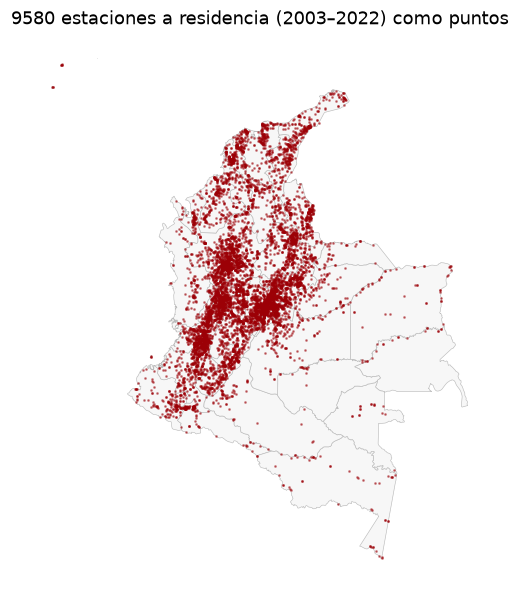

In [12]:
ax = deptos.plot(color="#F7F7F7", edgecolor="#BBBBBB", linewidth=0.4, figsize=(6.5, 6.5))
estaciones.plot(ax=ax, color=ROJO, markersize=0.7, alpha=0.45); ax.set_axis_off()
ax.set_title(f"{len(estaciones)} estaciones a residencia (2003–2022) como puntos");

> **Unión espacial (*spatial join*)** — relaciona dos capas por su posición: para cada punto se busca el polígono que lo contiene (predicado `within`) y se le copia su código. Después se agrupa por polígono y se cuenta.

In [13]:
# Reproyectar a un sistema en metros
deptos_m = deptos.to_crs(epsg=9377)

# Calcular área en m²
deptos["area_km2"] = deptos_m.geometry.area / 1_000_000
deptos

,source,id,name,geometry,area_km2
0,https://simplemaps.com,CONAR,Nariño,"MULTIPOLYGON (((-78.0739 2.64682, -77.98392 2....",31111.721885
1,https://simplemaps.com,COPUT,Putumayo,"POLYGON ((-77.10386 0.35414, -77.10188 0.3607,...",25419.612926
2,https://simplemaps.com,COCHO,Chocó,"MULTIPOLYGON (((-76.98546 8.25618, -76.98426 8...",46977.438787
3,https://simplemaps.com,COGUA,Guainía,"POLYGON ((-69.84118 1.70758, -69.84155 1.7078,...",71485.286233
4,https://simplemaps.com,COVAU,Vaupés,"POLYGON ((-70.10497 2.10116, -70.1083 2.05879,...",51766.234631
5,https://simplemaps.com,COAMA,Amazonas,"POLYGON ((-74.41472 -0.56376, -73.86414 -0.392...",109205.544164
6,https://simplemaps.com,COLAG,La Guajira,"POLYGON ((-72.91523 10.42817, -72.91588 10.428...",20471.932752
7,https://simplemaps.com,COCES,Cesar,"POLYGON ((-73.60579 10.84551, -73.45215 10.866...",22094.946163
8,https://simplemaps.com,CONSA,Norte de Santander,"POLYGON ((-73.62545 7.73454, -73.64033 7.74516...",21766.535355
9,https://simplemaps.com,COARA,Arauca,"POLYGON ((-71.96402 7.00592, -71.88101 6.9866,...",23717.885687


In [14]:
union = gpd.sjoin(estaciones, deptos[["name", "geometry"]], how="inner", predicate="within")
conteo = union.groupby("name").size()
deptos["n_estaciones"] = deptos.name.map(conteo).fillna(0).astype(int)        # la tasa: eventos por km²
deptos["estaciones_km2"] = deptos.n_estaciones / deptos.area_km2
deptos["estaciones_x_km2"] = deptos.n_estaciones * deptos.area_km2  
deptos["log_n_estaciones"] = np.log10(deptos["n_estaciones"])
deptos["log_n_km2"] = np.log10(deptos["n_estaciones"]) / deptos.area_km2
deptos[["name", "n_estaciones"]].sort_values("n_estaciones", ascending=False).head(8).round(2)

,name,n_estaciones
14,Antioquia,1514
31,Cundinamarca,1130
13,Valle del Cauca,819
28,Santander,550
10,Boyacá,549
29,Tolima,510
24,Caldas,405
22,Huila,383


Un detalle de la unión para un barrio: los puntos rojos caen dentro (cuentan), los grises quedan en los vecinos.

In [15]:
deptos

,source,id,name,geometry,area_km2,n_estaciones,estaciones_km2,estaciones_x_km2,log_n_estaciones,log_n_km2
0,https://simplemaps.com,CONAR,Nariño,"MULTIPOLYGON (((-78.0739 2.64682, -77.98392 2....",31111.721885,160,0.005143,4.977876e+06,2.204120,0.000071
1,https://simplemaps.com,COPUT,Putumayo,"POLYGON ((-77.10386 0.35414, -77.10188 0.3607,...",25419.612926,100,0.003934,2.541961e+06,2.000000,0.000079
2,https://simplemaps.com,COCHO,Chocó,"MULTIPOLYGON (((-76.98546 8.25618, -76.98426 8...",46977.438787,113,0.002405,5.308451e+06,2.053078,0.000044
3,https://simplemaps.com,COGUA,Guainía,"POLYGON ((-69.84118 1.70758, -69.84155 1.7078,...",71485.286233,14,0.000196,1.000794e+06,1.146128,0.000016
4,https://simplemaps.com,COVAU,Vaupés,"POLYGON ((-70.10497 2.10116, -70.1083 2.05879,...",51766.234631,17,0.000328,8.800260e+05,1.230449,0.000024
5,https://simplemaps.com,COAMA,Amazonas,"POLYGON ((-74.41472 -0.56376, -73.86414 -0.392...",109205.544164,50,0.000458,5.460277e+06,1.698970,0.000016
6,https://simplemaps.com,COLAG,La Guajira,"POLYGON ((-72.91523 10.42817, -72.91588 10.428...",20471.932752,204,0.009965,4.176274e+06,2.309630,0.000113
7,https://simplemaps.com,COCES,Cesar,"POLYGON ((-73.60579 10.84551, -73.45215 10.866...",22094.946163,273,0.012356,6.031920e+06,2.436163,0.000110
8,https://simplemaps.com,CONSA,Norte de Santander,"POLYGON ((-73.62545 7.73454, -73.64033 7.74516...",21766.535355,291,0.013369,6.334062e+06,2.463893,0.000113
9,https://simplemaps.com,COARA,Arauca,"POLYGON ((-71.96402 7.00592, -71.88101 6.9866,...",23717.885687,38,0.001602,9.012797e+05,1.579784,0.000067


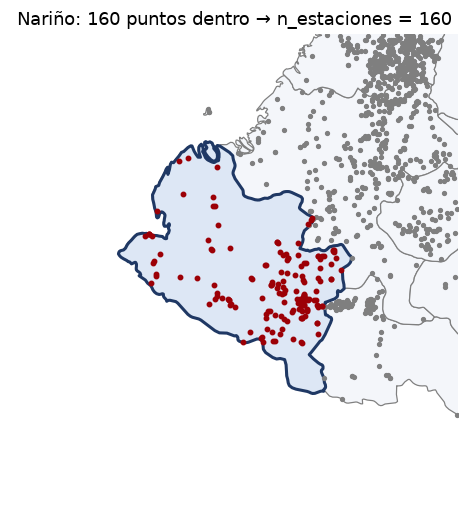

In [16]:
name = "Nariño"
bound = 1
bb = deptos[deptos.name == name].iloc[0]
minx, miny, maxx, maxy = bb.geometry.bounds
fig, ax = plt.subplots(figsize=(6.5, 5.5))
deptos.cx[minx - bound:maxx + bound, miny - bound:maxy + bound].plot(ax=ax, color="#F4F6FA", edgecolor=GRIS, linewidth=0.8)
gpd.GeoSeries([bb.geometry]).plot(ax=ax, color="#DDE7F5", edgecolor=AZUL, linewidth=2)
hz = estaciones.cx[minx - bound:maxx + bound, miny - bound:maxy + bound]; dentro = hz.within(bb.geometry)
hz[~dentro].plot(ax=ax, color=GRIS, markersize=6); hz[dentro].plot(ax=ax, color=ROJO, markersize=8)
ax.set_xlim(minx - bound, maxx + bound); ax.set_ylim(miny - bound, maxy + bound); ax.set_axis_off()
ax.set_title(f"{name}: {int(dentro.sum())} puntos dentro → n_estaciones = {bb.n_estaciones}");

## 2. Describir la variable antes de mapearla

count      33.0
mean      290.3
std       330.1
min         8.0
25%        91.0
50%       210.0
75%       379.0
max      1514.0
Name: n_estaciones, dtype: float64
asimetría: -0.6


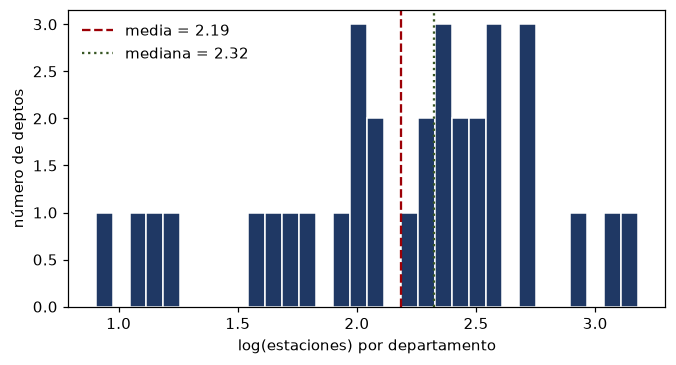

In [17]:
y = deptos.log_n_estaciones.values
print(deptos.n_estaciones.describe().round(1)); print("asimetría:", round(pd.Series(y).skew(), 2))
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(y, bins=32, color=AZUL, edgecolor="white")
ax.axvline(y.mean(), color=ROJO, ls="--", label=f"media = {y.mean():.2f}"); ax.axvline(np.median(y), color="#375623", ls=":", label=f"mediana = {np.median(y):.2f}")
ax.set_xlabel("log(estaciones) por departamento"); ax.set_ylabel("número de deptos"); ax.legend(frameon=False);

## 3. El mapa coroplético y sus decisiones

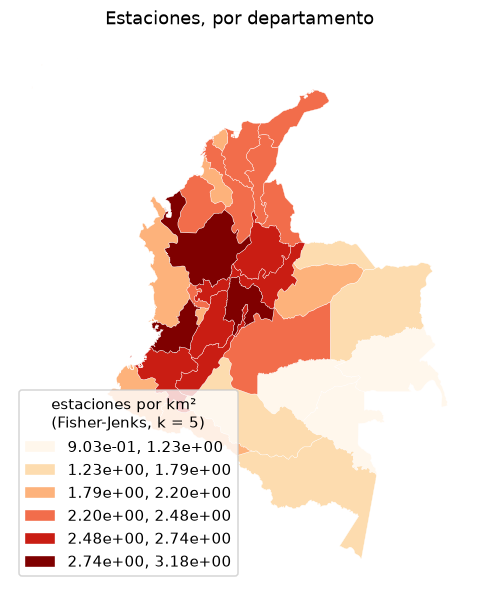

In [18]:
fig, ax = plt.subplots(figsize=(7, 6.5))
deptos.plot(column="log_n_estaciones", scheme="FisherJenks", k=6, cmap="OrRd", edgecolor="white", linewidth=0.25, ax=ax,
             legend=True, legend_kwds={"title": "estaciones por km²\n(Fisher-Jenks, k = 5)", "loc": "lower left", "fmt": "{:.2e}"})
ax.set_axis_off(); ax.set_title("Estaciones, por departamento");

## 4. ¿Cuántas clases? R/ 6

Freedman–Diaconis: ancho = 0 estaciones/km² → k = 6


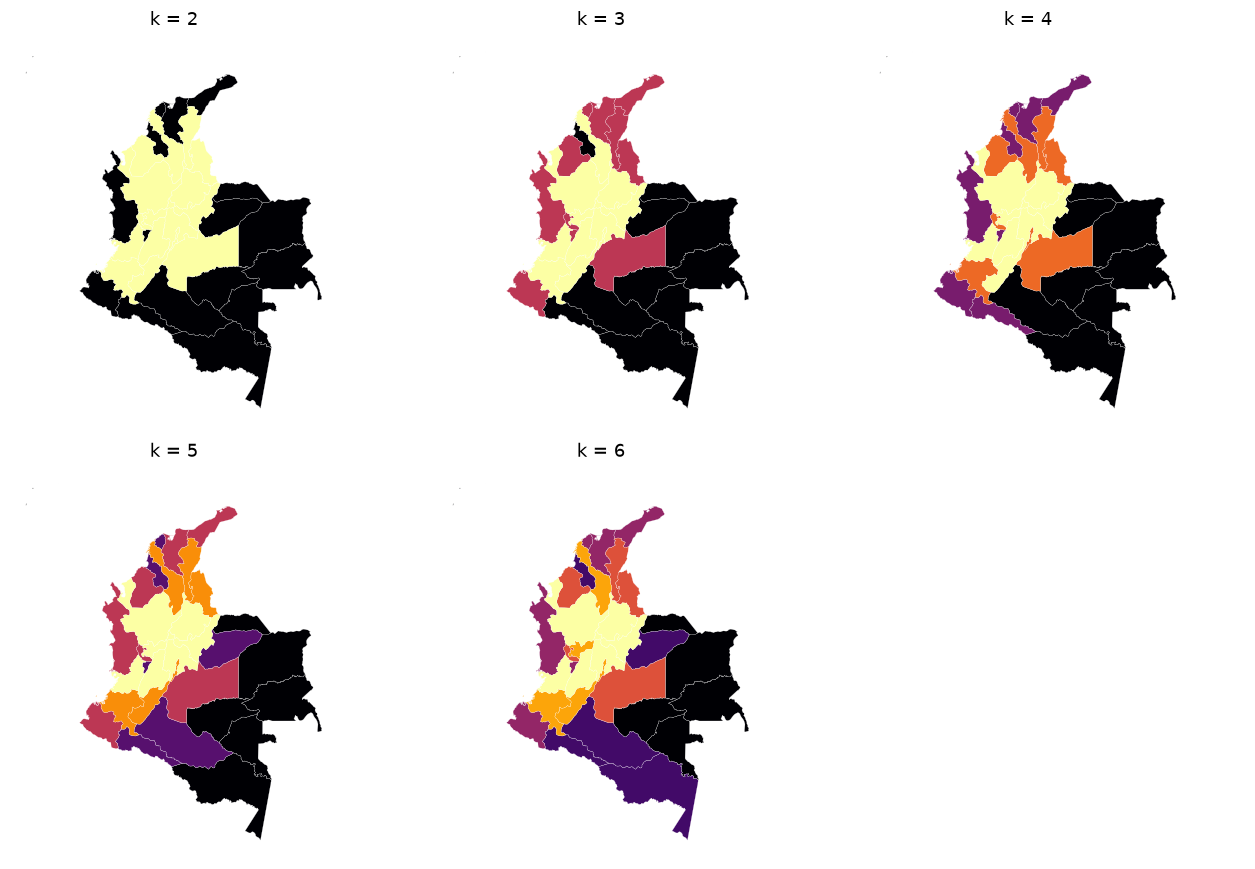

In [19]:
import math
import numpy as np
import matplotlib.pyplot as plt

def freedman_diaconis(x):
    x = np.asarray(x); riq = np.subtract(*np.percentile(x, [75, 25]))
    w = 2 * riq * len(x) ** (-1 / 3)
    return w, int(np.ceil((x.max() - x.min()) / w))

w_fd, k_fd = freedman_diaconis(y)
print(f"Freedman–Diaconis: ancho = {w_fd:.0f} estaciones/km² → k = {k_fd}")

# Valores de k de 2 a k_fd
ks = list(range(2, k_fd + 1))

# Configurar cuadrícula de 3 columnas
n_cols = 3
n_rows = math.ceil(len(ks) / n_cols)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axs = np.atleast_1d(axs).flatten()  # Aplanar la matriz para iterar fácilmente

# Dibujar cada mapa
for ax, k in zip(axs, ks):
    deptos.plot(column="log_n_estaciones", scheme="Quantiles", k=k, cmap="inferno", edgecolor="white", linewidth=0.15, ax=ax)
    ax.set_axis_off()
    ax.set_title(f"k = {k}")

# Ocultar ejes sobrantes en la última fila si len(ks) no es múltiplo de 3
for ax in axs[len(ks):]:
    ax.axis("off")

# Agregar la barra de color
#fig.colorbar(axs[-1].collections[0], ax=axs, orientation="vertical", pad=0.03, shrink=0.6)

plt.tight_layout()
plt.show()

## 5. ¿Dónde cortar? Los métodos de clasificación: Fisher-Jenks

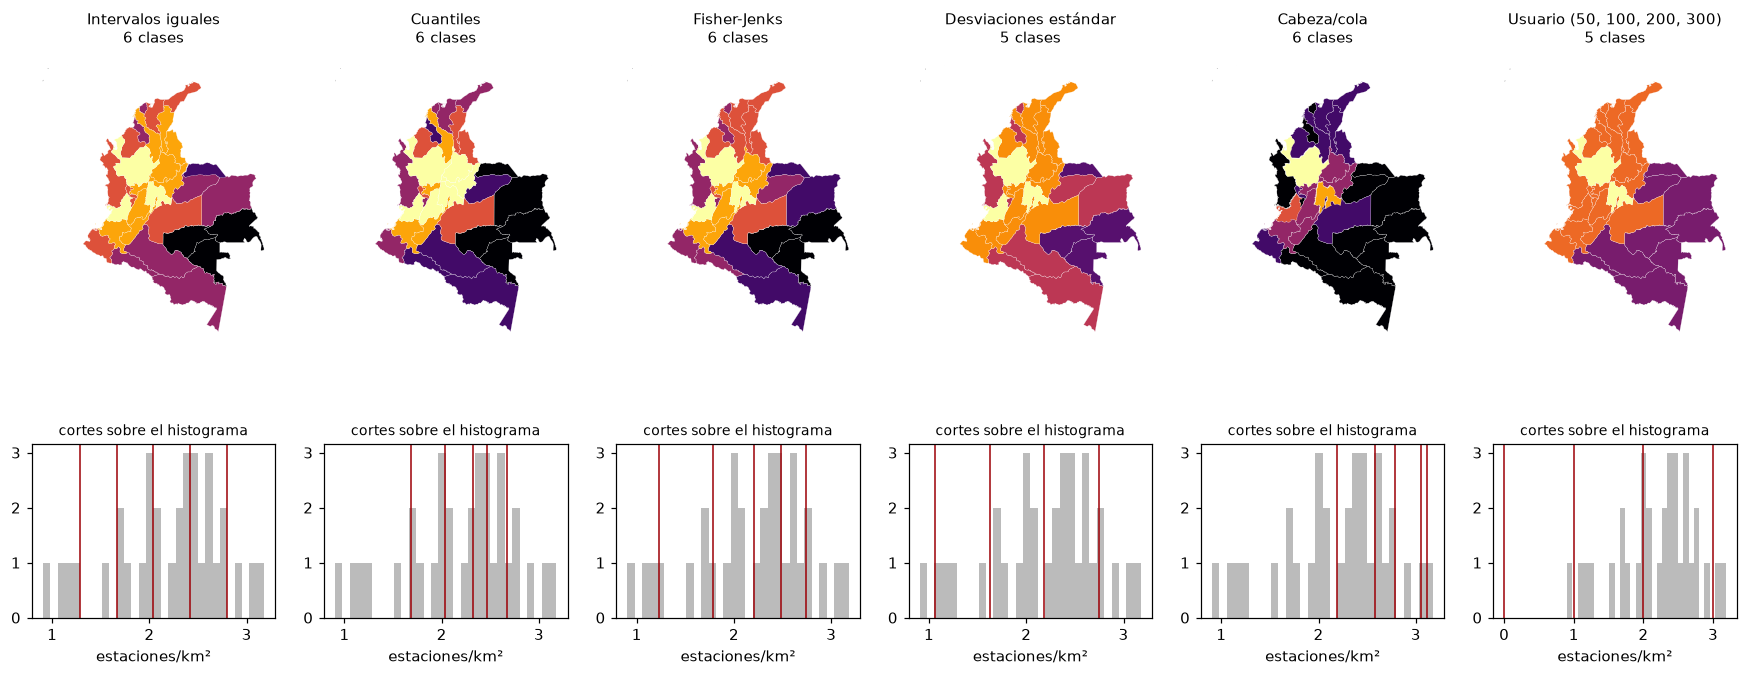

In [20]:
esquemas = {
    "Intervalos iguales": mc.EqualInterval(y, k=6), "Cuantiles": mc.Quantiles(y, k=6), "Fisher-Jenks": mc.FisherJenks(y, k=6),
    "Desviaciones estándar": mc.StdMean(y, anchor=True), "Cabeza/cola": mc.HeadTailBreaks(y), "Usuario (50, 100, 200, 300)": mc.UserDefined(y, [0, 1, 2, 3]),
}
fig, axs = plt.subplots(2, 6, figsize=(20, 7.2), gridspec_kw={"height_ratios": [2.2, 1]})
for c, (nombre, cl) in enumerate(esquemas.items()):
    deptos.assign(clase=cl.yb).plot(column="clase", cmap="inferno", categorical=True, edgecolor="white", linewidth=0.15, ax=axs[0, c])
    axs[0, c].set_axis_off(); axs[0, c].set_title(f"{nombre}\n{cl.k} clases", fontsize=10)
    axs[1, c].hist(y, bins=30, color="#BBBBBB")
    for b_ in cl.bins[:-1]: axs[1, c].axvline(b_, color=ROJO, lw=1)
    axs[1, c].set_xlabel("estaciones/km²"); axs[1, c].set_title("cortes sobre el histograma", fontsize=9)

In [21]:
pd.DataFrame({n: {"cortes": [round(v) for v in cl.bins], "deptos por clase": list(cl.counts), "ADCM": round(cl.adcm, 10)} for n, cl in esquemas.items()}).T

,cortes,deptos por clase,ADCM
Intervalos iguales,"[1, 2, 2, 2, 3, 3]","[4, 1, 7, 8, 10, 3]",3.24957
Cuantiles,"[2, 2, 2, 2, 3, 3]","[6, 5, 6, 5, 5, 6]",3.920223
Fisher-Jenks,"[1, 2, 2, 2, 3, 3]","[4, 4, 7, 8, 7, 3]",2.1214
Desviaciones estándar,"[1, 2, 2, 3, 3]","[1, 4, 9, 16, 3]",4.037444
Cabeza/cola,"[2, 3, 3, 3, 3, 3]","[14, 10, 6, 1, 1, 1]",5.735747
"Usuario (50, 100, 200, 300)","[0, 1, 2, 3, 3]","[0, 1, 9, 21, 2]",6.799163


# Vecinos

In [22]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from libpysal import weights
from esda.moran import Moran

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
AZUL, ROJO, AZUL_CLARO, ROSA, GRIS = "#1F3864", "#9C0006", "#9CC3FF", "#F4A6A6", "#7F7F7F"

# 1

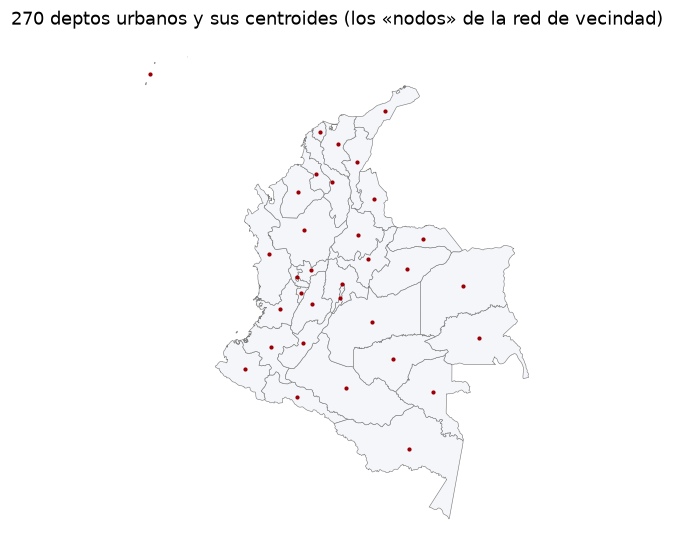

In [23]:
ax = deptos.plot(color="#F4F6FA", edgecolor=GRIS, linewidth=0.4, figsize=(6, 6))
deptos.geometry.centroid.plot(ax=ax, color=ROJO, markersize=3)
ax.set_axis_off(); ax.set_title("270 deptos urbanos y sus centroides (los «nodos» de la red de vecindad)");

## 2. La matriz de pesos espaciales W

In [24]:
W_abc = np.array([[0, 1, 0],
                  [1, 0, 1],
                  [0, 1, 0]])
print(pd.DataFrame(W_abc, index=list("ABC"), columns=list("ABC")))
print("S0 =", W_abc.sum(), "| cardinalidad (vecinos por fila):", W_abc.sum(axis=1))

   A  B  C
A  0  1  0
B  1  0  1
C  0  1  0
S0 = 4 | cardinalidad (vecinos por fila): [1 2 1]


In [25]:
def mapa_vecinos(w, gdf, nombre, ax=None, titulo=None, color=AZUL_CLARO, margen=1, lineas=False):
    # Pinta el barrio `nombre` (azul), sus vecinos según `w` (claro) y el resto del entorno (gris).
    i = int(gdf.index[gdf.name == nombre][0])
    vec = list(w.neighbors[i])
    if ax is None: fig, ax = plt.subplots(figsize=(5.5, 5.5))
    minx, miny, maxx, maxy = pd.concat([gdf.iloc[vec], gdf.iloc[[i]]]).total_bounds
    gdf.cx[minx - margen:maxx + margen, miny - margen:maxy + margen].plot(ax=ax, color="#F7F7F7", edgecolor="#BBBBBB", linewidth=0.5)
    gdf.iloc[vec].plot(ax=ax, color=color, edgecolor=GRIS, linewidth=0.7)
    gdf.iloc[[i]].plot(ax=ax, color=AZUL)
    if lineas:
        c = gdf.geometry.centroid
        for j in vec: ax.plot([c[i].x, c[j].x], [c[i].y, c[j].y], color=AZUL, lw=1)
        ax.scatter(c.x, c.y, s=5, color=GRIS)
    for r in gdf.iloc[vec].itertuples():
        ax.annotate(r.name, (r.geometry.centroid.x, r.geometry.centroid.y), fontsize=7, ha="center")
    ax.set_xlim(minx - margen, maxx + margen); ax.set_ylim(miny - margen, maxy + margen); ax.set_axis_off()
    ax.set_title(titulo or f"{nombre}: {len(vec)} vecinos", fontsize=10)
    return ax

def resumen_w(w, nombre):
    card = pd.Series(w.cardinalities)
    return pd.Series({"configuración": nombre, "n": w.n, "vecinos mín.": card.min(), "vecinos máx.": card.max(),
                      "vecinos prom.": round(card.mean(), 2), "islas": len(w.islands), "% no nulo": round(w.pct_nonzero, 2),
                      "simétrica": bool(np.allclose(w.sparse.toarray(), w.sparse.toarray().T))})

DPTO = "Cundinamarca"   # cambie el nombre para explorar otro barrio

## 3. Contigüidad de torre (*rook*)

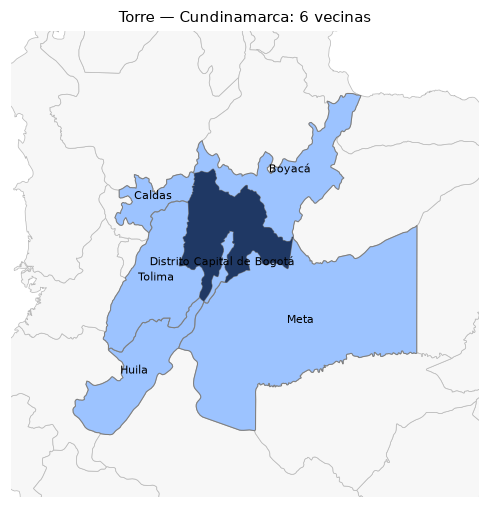

In [26]:
w_torre = weights.Rook.from_dataframe(deptos, use_index=False)
mapa_vecinos(w_torre, deptos, DPTO, titulo=f"Torre — {DPTO}: {len(w_torre.neighbors[int(deptos.index[deptos.name == DPTO][0])])} vecinas");

In [27]:
i = int(deptos.index[deptos.name == DPTO][0])
print("vecinos de", DPTO, "→", [deptos.name[j] for j in w_torre.neighbors[i]])
fila = pd.Series(w_torre.sparse.toarray()[i], index=deptos.name)
print("\nfila de la matriz (solo las celdas no nulas):"); print(fila[fila > 0])
print("\nislas:", w_torre.islands, "| celdas no nulas de W:", round(w_torre.pct_nonzero, 2), "%")

vecinos de Cundinamarca → ['Boyacá', 'Huila', 'Caldas', 'Meta', 'Distrito Capital de Bogotá', 'Tolima']

fila de la matriz (solo las celdas no nulas):
name
Boyacá                        1.0
Huila                         1.0
Caldas                        1.0
Meta                          1.0
Distrito Capital de Bogotá    1.0
Tolima                        1.0
dtype: float64

islas: [20] | celdas no nulas de W: 13.04 %


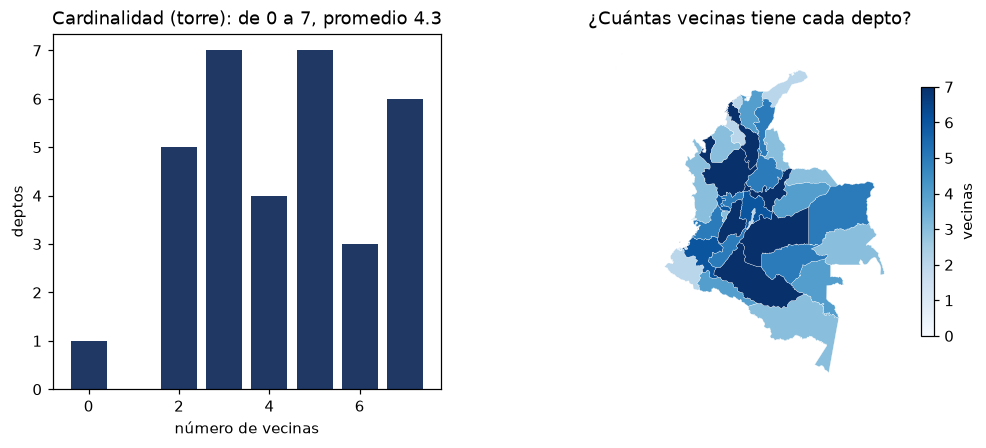

In [28]:
card = pd.Series(w_torre.cardinalities)
fig, axs = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [1, 1.2]})
axs[0].bar(*np.unique(card, return_counts=True), color=AZUL); axs[0].set_xlabel("número de vecinas"); axs[0].set_ylabel("deptos")
axs[0].set_title(f"Cardinalidad (torre): de {card.min()} a {card.max()}, promedio {card.mean():.1f}")
deptos.assign(c=card.values).plot(column="c", cmap="Blues", ax=axs[1], edgecolor="white", linewidth=0.2, legend=True, legend_kwds={"shrink": .7, "label": "vecinas"})
axs[1].set_axis_off(); axs[1].set_title("¿Cuántas vecinas tiene cada depto?");

## 4. Contigüidad de reina (*queen*)

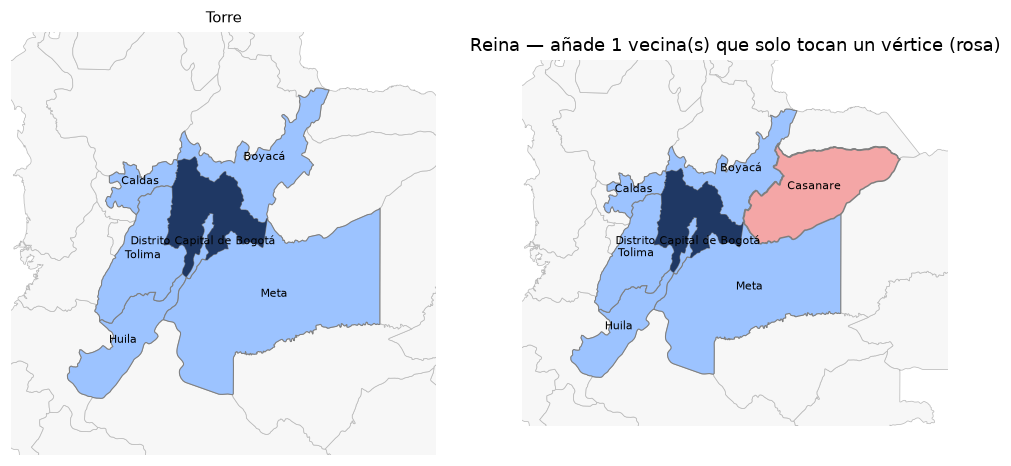

In [29]:
w_reina = weights.Queen.from_dataframe(deptos, use_index=False)
fig, axs = plt.subplots(1, 2, figsize=(11, 5))
mapa_vecinos(w_torre, deptos, DPTO, ax=axs[0], titulo="Torre")
mapa_vecinos(w_reina, deptos, DPTO, ax=axs[1], titulo="Reina")
# resaltar en rosa las vecinas que solo añade la reina
solo_reina = set(w_reina.neighbors[i]) - set(w_torre.neighbors[i])
if solo_reina: deptos.iloc[list(solo_reina)].plot(ax=axs[1], color=ROSA, edgecolor=GRIS)
axs[1].set_title(f"Reina — añade {len(solo_reina)} vecina(s) que solo tocan un vértice (rosa)");

deptos cuyo vecindario cambia al pasar de torre a reina: 6 de 33


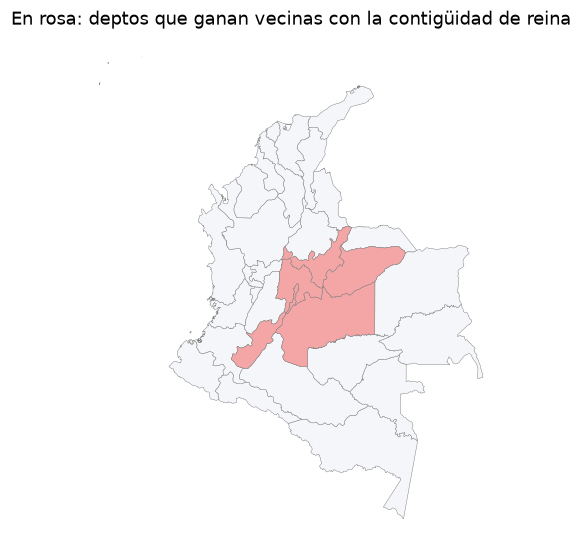

In [30]:
cambian = [k for k in range(len(deptos)) if set(w_torre.neighbors[k]) != set(w_reina.neighbors[k])]
print(f"deptos cuyo vecindario cambia al pasar de torre a reina: {len(cambian)} de {len(deptos)}")
ax = deptos.plot(color="#F4F6FA", edgecolor=GRIS, linewidth=0.3, figsize=(6, 6))
deptos.iloc[cambian].plot(ax=ax, color=ROSA, edgecolor=GRIS, linewidth=0.3)
ax.set_axis_off(); ax.set_title("En rosa: deptos que ganan vecinas con la contigüidad de reina");

## 5. De la matriz binaria a la estandarizada por filas, y el rezago espacial


In [31]:
W_est = W_abc / W_abc.sum(axis=1, keepdims=True)
y_abc = np.array([10, 20, 40])
print("W estandarizada por filas:\n", pd.DataFrame(W_est, index=list("ABC"), columns=list("ABC")).round(2))
print("\nrezago Wy =", W_est @ y_abc, "  (A: 20 · B: (10+40)/2 = 25 · C: 20)")

W estandarizada por filas:
      A    B    C
A  0.0  1.0  0.0
B  0.5  0.0  0.5
C  0.0  1.0  0.0

rezago Wy = [20. 25. 20.]   (A: 20 · B: (10+40)/2 = 25 · C: 20)


In [32]:
# En libpysal la estandarización es una propiedad del objeto W
w_reina.transform = "R"
fila_bin = pd.Series(weights.Queen.from_dataframe(deptos, use_index=False).sparse.toarray()[i], index=deptos.name)
fila_est = pd.Series(w_reina.sparse.toarray()[i], index=deptos.name)
pd.DataFrame({"binaria": fila_bin[fila_bin > 0], "por filas": fila_est[fila_est > 0].round(3)})

('WARNING: ', 20, ' is an island (no neighbors)')


,binaria,por filas
name,,
Boyacá,1.0,0.143
Huila,1.0,0.143
Caldas,1.0,0.143
Casanare,1.0,0.143
Meta,1.0,0.143
Distrito Capital de Bogotá,1.0,0.143
Tolima,1.0,0.143


In [33]:
y = deptos.log_n_estaciones.values
deptos["rezago"] = weights.lag_spatial(w_reina, y)      # Wy con la W estandarizada por filas
print(deptos[["name", "log_n_estaciones", "rezago"]].round(1).head(8))

         name  log_n_estaciones  rezago
0      Nariño               2.2     2.3
1    Putumayo               2.0     2.1
2       Chocó               2.1     2.8
3     Guainía               1.1     1.3
4      Vaupés               1.2     1.4
5    Amazonas               1.7     1.7
6  La Guajira               2.3     2.4
7       Cesar               2.4     2.5


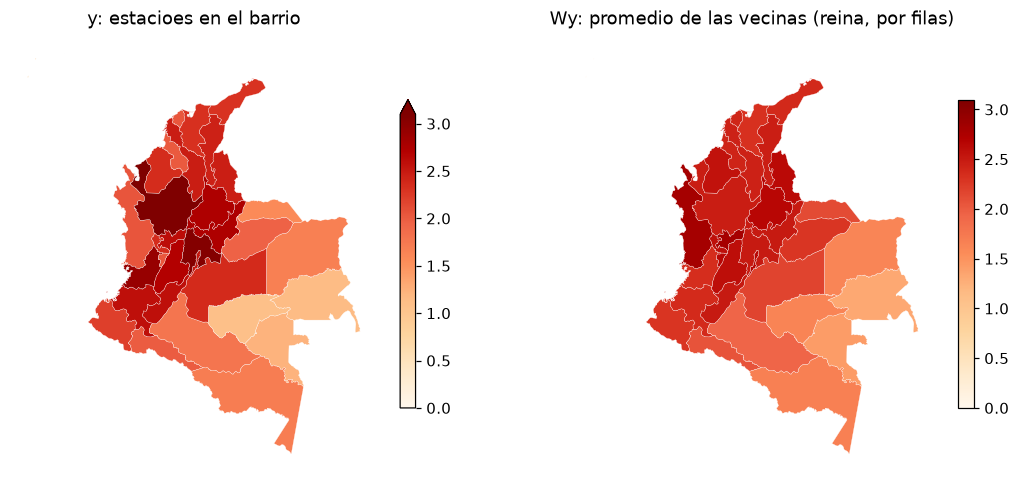

In [34]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5.2)); vmax = np.percentile(y, 98)
deptos.plot(column="log_n_estaciones", cmap="OrRd", vmin=0, vmax=vmax, ax=axs[0], edgecolor="white", linewidth=0.2, legend=True, legend_kwds={"shrink": .7})
deptos.plot(column="rezago", cmap="OrRd", vmin=0, vmax=vmax, ax=axs[1], edgecolor="white", linewidth=0.2, legend=True, legend_kwds={"shrink": .7})
axs[0].set_title("y: estacioes en el barrio"); axs[1].set_title("Wy: promedio de las vecinas (reina, por filas)")
for ax in axs: ax.set_axis_off()

## 6. Pesos por distancia I: k vecinas más cercanas (kNN)


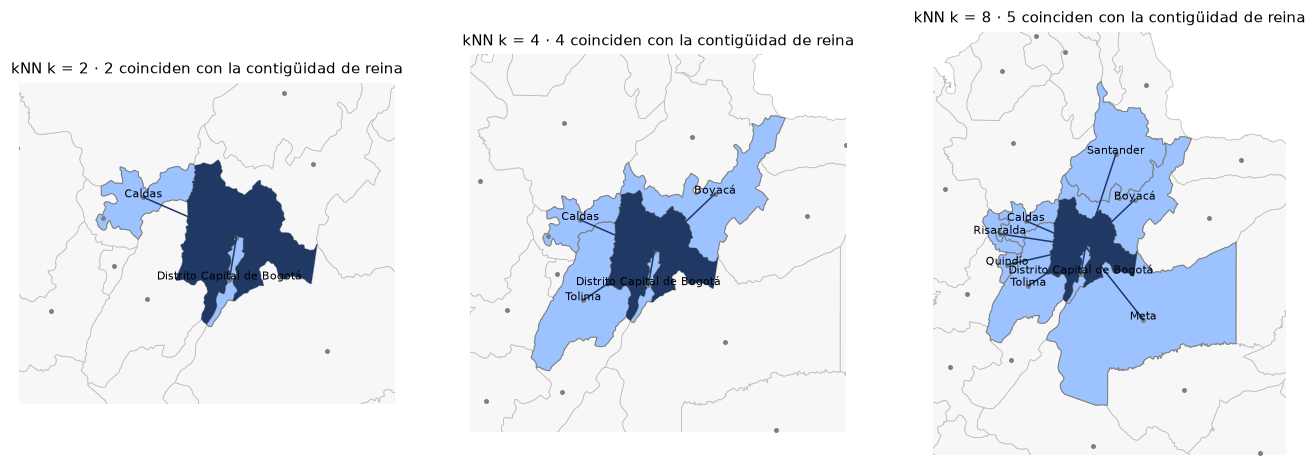

In [35]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for ax, k in zip(axs, [2, 4, 8]):
    w_k = weights.KNN.from_dataframe(deptos, k=k, use_index=False)
    comunes = len(set(w_k.neighbors[i]) & set(w_reina.neighbors[i]))
    mapa_vecinos(w_k, deptos, DPTO, ax=ax, lineas=True, titulo=f"kNN k = {k} · {comunes} coinciden con la contigüidad de reina")

In [36]:
w_k4 = weights.KNN.from_dataframe(deptos, k=4, use_index=False)
M = w_k4.sparse.toarray()
asim = [(deptos.name[a], deptos.name[b]) for a in range(len(M)) for b in range(len(M)) if M[a, b] == 1 and M[b, a] == 0]
print(f"kNN k=4: {len(asim)} relaciones no recíprocas de {int(M.sum())}. Ejemplos:")
for a, b in asim[:5]: print(f"  {b} está entre las 4 más cercanas de {a}, pero {a} no entre las de {b}")

kNN k=4: 48 relaciones no recíprocas de 132. Ejemplos:
  Valle del Cauca está entre las 4 más cercanas de Nariño, pero Nariño no entre las de Valle del Cauca
  Huila está entre las 4 más cercanas de Nariño, pero Nariño no entre las de Huila
  Huila está entre las 4 más cercanas de Putumayo, pero Putumayo no entre las de Huila
  Caldas está entre las 4 más cercanas de Chocó, pero Chocó no entre las de Caldas
  Quindío está entre las 4 más cercanas de Chocó, pero Chocó no entre las de Quindío


## 7. Pesos por distancia II: banda de distancia

In [37]:
deptos_metros = deptos.to_crs(epsg=9377)

In [38]:
distancias_entre_deptos = np.array(np.abs(
    np.array(deptos_metros.geometry.centroid.x**2 + deptos_metros.geometry.centroid.y**2)[:,None] 
    -
    np.array(deptos_metros.geometry.centroid.x**2 + deptos_metros.geometry.centroid.y**2)[None, :] 
))**0.5

distancias_entre_deptos = distancias_entre_deptos[distancias_entre_deptos != 0]

dist_deptos_min = distancias_entre_deptos.min()
dist_deptos_max = distancias_entre_deptos.max()

dist_deptos_max, dist_deptos_min

(np.float64(3279189.524631475), np.float64(50226.618700310755))

Text(0.5, 0, 'Dist [km]')

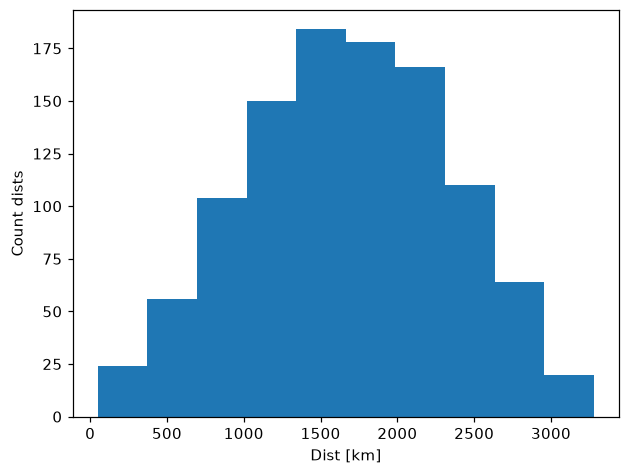

In [39]:
plt.hist(distancias_entre_deptos.flatten() * 1e-3)
plt.ylabel("Count dists")
plt.xlabel("Dist [km]")

umbral mínimo sin islas: 761259 m


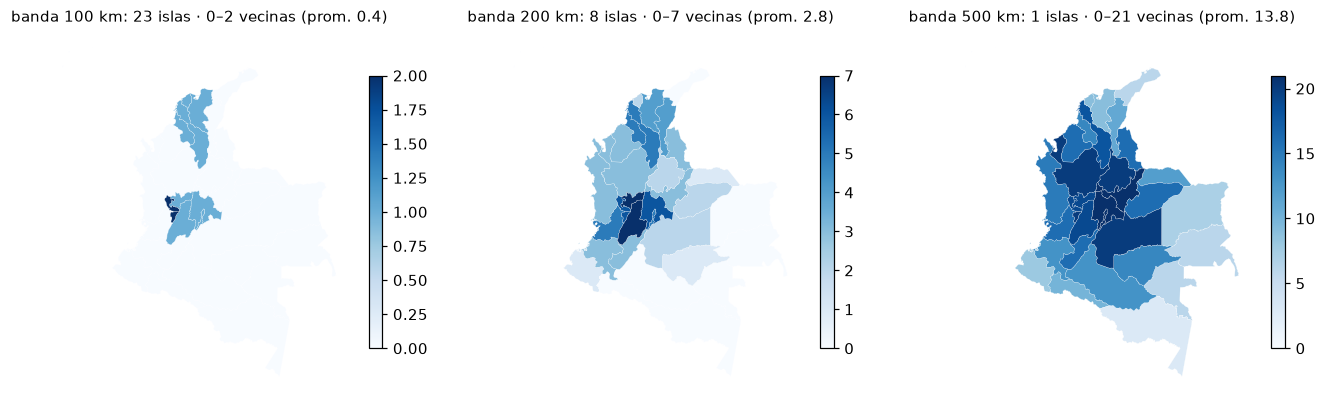

In [40]:
coords = np.column_stack([deptos_metros.geometry.centroid.x, deptos_metros.geometry.centroid.y])
d_min = weights.min_threshold_distance(coords)
print(f"umbral mínimo sin islas: {d_min:.0f} m")
fig, axs = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, d in zip(axs, [100e3, 200e3, 500e3]):
    w_d = weights.DistanceBand.from_dataframe(deptos_metros, threshold=d, use_index=False, silence_warnings=True)
    card = pd.Series(w_d.cardinalities)
    deptos.assign(c=card.values).plot(column="c", cmap="Blues", ax=ax, edgecolor="white", linewidth=0.15, legend=True, legend_kwds={"shrink": .7})
    ax.set_axis_off(); ax.set_title(f"banda {d*1e-3:.0f} km: {len(w_d.islands)} islas · {card.min()}–{card.max()} vecinas (prom. {card.mean():.1f})", fontsize=10)

## 8. Pesos por núcleo (*kernel*): el peso decrece con la distancia

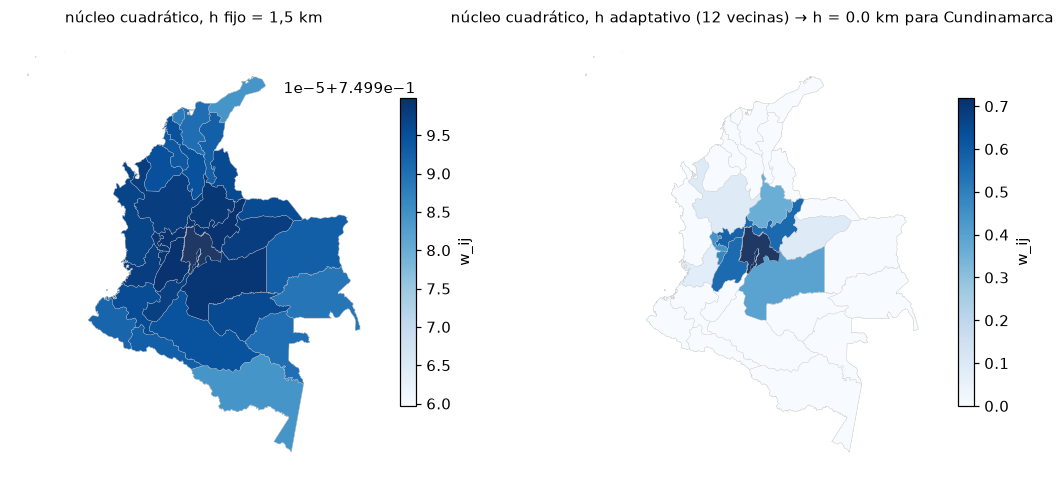

In [41]:
w_kf = weights.Kernel.from_dataframe(deptos, bandwidth=1500, function="quadratic", use_index=False)       # h fijo = 1,5 km
w_ka = weights.Kernel.from_dataframe(deptos, fixed=False, k=12, function="quadratic", use_index=False)   # h adaptativo: hasta la 12.ª vecina
fig, axs = plt.subplots(1, 2, figsize=(12, 5.2))
c = deptos.geometry.centroid
for ax, w_, t in [(axs[0], w_kf, "núcleo cuadrático, h fijo = 1,5 km"), (axs[1], w_ka, f"núcleo cuadrático, h adaptativo (12 vecinas) → h = {w_ka.bandwidth[i][0]/1000:.1f} km para {DPTO}")]:
    pesos = pd.Series(w_.sparse.toarray()[i])
    pesos[i] = np.nan                                   # el propio barrio no cuenta
    deptos.cx[c[i].x - 3200:c[i].x + 3200, c[i].y - 3200:c[i].y + 3200].plot(ax=ax, color="#F7F7F7", edgecolor="#BBBBBB", linewidth=0.3)
    deptos.assign(w=pesos.values).plot(column="w", cmap="Blues", ax=ax, edgecolor="#CCCCCC", linewidth=0.2, legend=True, legend_kwds={"shrink": .7, "label": "w_ij"}, missing_kwds={"color": AZUL})
    #ax.set_xlim(c[i].x - 3200, c[i].x + 3200); ax.set_ylim(c[i].y - 3200, c[i].y + 3200); 
    ax.set_axis_off(); ax.set_title(t, fontsize=10)

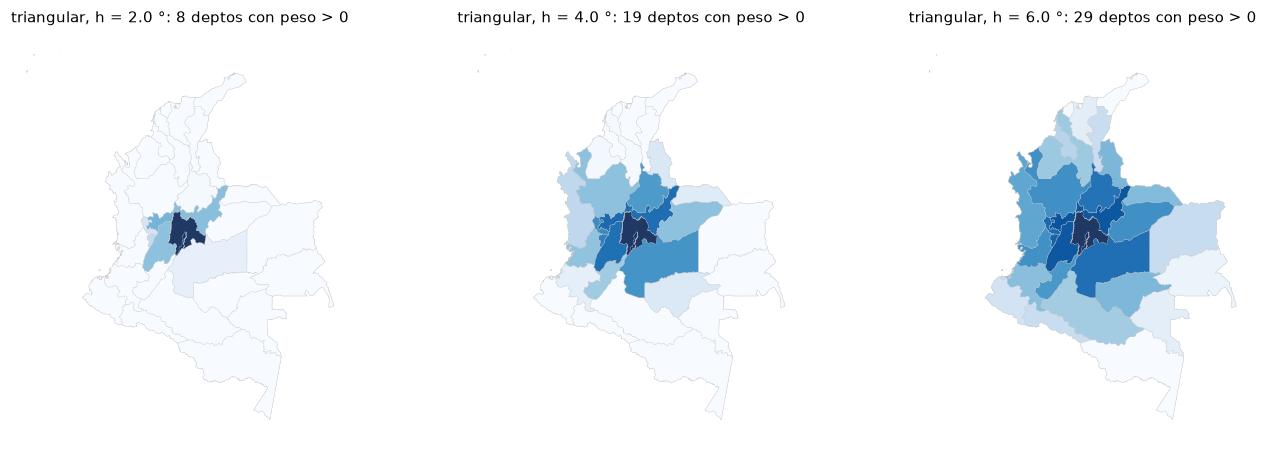

In [42]:
# La forma de K importa poco; h importa mucho: el mismo barrio con tres anchos de banda
fig, axs = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, h_ in zip(axs, [2, 4, 6]):
    w_ = weights.Kernel.from_dataframe(deptos, bandwidth=h_, function="triangular", use_index=False)
    pesos = pd.Series(w_.sparse.toarray()[i]); pesos[i] = np.nan
    deptos.cx[c[i].x - 3500:c[i].x + 3500, c[i].y - 3500:c[i].y + 3500].plot(ax=ax, color="#F7F7F7", edgecolor="#BBBBBB", linewidth=0.3)
    deptos.assign(w=pesos.values).plot(column="w", cmap="Blues", ax=ax, edgecolor="#CCCCCC", linewidth=0.2, missing_kwds={"color": AZUL})
    #ax.set_xlim(c[i].x - 3500, c[i].x + 3500); ax.set_ylim(c[i].y - 3500, c[i].y + 3500);
    ax.set_axis_off()
    ax.set_title(f"triangular, h = {h_:.1f} °: {(pesos > 0).sum()} deptos con peso > 0", fontsize=10)

## 9. Comparar las configuraciones sobre los mismos datos


In [43]:
configs = {
    "contigüidad torre": weights.Rook.from_dataframe(deptos, use_index=False),
    "contigüidad reina": weights.Queen.from_dataframe(deptos, use_index=False),
    "kNN k = 4": weights.KNN.from_dataframe(deptos, k=4, use_index=False),
    "kNN k = 8": weights.KNN.from_dataframe(deptos, k=8, use_index=False),
    "banda 2 °": weights.DistanceBand.from_dataframe(deptos, threshold=2, use_index=False, silence_warnings=True),
    "banda 4 °": weights.DistanceBand.from_dataframe(deptos, threshold=4, use_index=False, silence_warnings=True),
    "núcleo fijo 3 km": weights.Kernel.from_dataframe(deptos, bandwidth=3, function="quadratic", use_index=False),
    "núcleo adaptativo k=12": weights.Kernel.from_dataframe(deptos, fixed=False, k=12, function="quadratic", use_index=False),
}
filas = []
np.random.seed(1)
for nombre, w_ in configs.items():
    r = resumen_w(w_, nombre)
    w_.transform = "R"
    r["I de Moran (hurtos/km²)"] = round(Moran(y, w_, permutations=999).I, 3)
    filas.append(r)
tabla = pd.DataFrame(filas).set_index("configuración"); tabla

('WARNING: ', 20, ' is an island (no neighbors)')
('WARNING: ', 20, ' is an island (no neighbors)')


,n,vecinos mín.,vecinos máx.,vecinos prom.,islas,% no nulo,simétrica,I de Moran (hurtos/km²)
configuración,,,,,,,,
contigüidad torre,33,0,7,4.30,1,13.04,True,0.526
contigüidad reina,33,0,8,4.48,1,13.59,True,0.513
kNN k = 4,33,4,4,4.00,0,12.12,False,0.438
kNN k = 8,33,8,8,8.00,0,24.24,False,0.273
banda 2 °,33,0,8,3.52,5,10.65,True,0.454
banda 4 °,33,0,20,11.88,1,36.00,True,0.322
núcleo fijo 3 km,33,1,14,8.58,0,25.99,True,0.712
núcleo adaptativo k=12,33,13,13,13.00,0,39.39,False,0.448


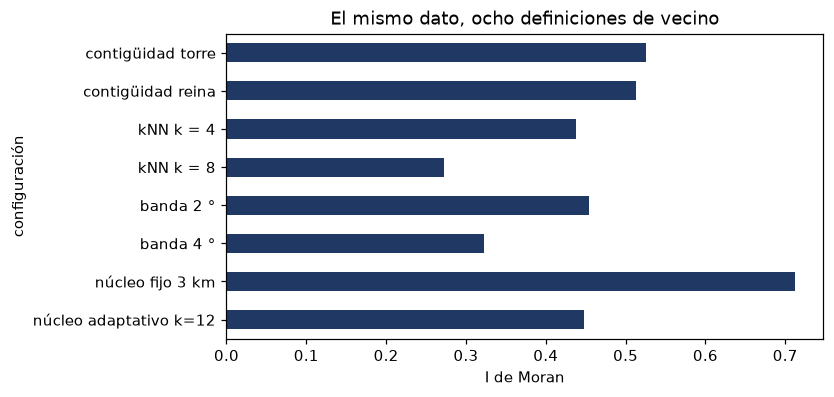

In [44]:
ax = tabla["I de Moran (hurtos/km²)"].plot.barh(color=AZUL, figsize=(7, 3.6)); ax.invert_yaxis()
ax.set_xlabel("I de Moran"); ax.set_title("El mismo dato, ocho definiciones de vecino");

## 10. Guardar y reutilizar una W


In [45]:
w_reina_cod = weights.Queen.from_dataframe(deptos, ids=deptos.id.tolist(), use_index=False)
w_reina_cod.to_file("w_deptos_reina.gal")
w_leida = weights.W.from_file("w_deptos_reina.gal")
print("vecinos de", DPTO, "(código", deptos.id[i] + "):", w_leida.neighbors[deptos.id[i]])

vecinos de Cundinamarca (código COCUN): ['COBOY', 'COMET', 'COCAL', 'COHUI', 'COCAS', 'CODC', 'COTOL']


# Autocorrelación espacial

In [46]:
# Importar librerías básicas
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import esda

# Librerías para análisis espacial
from libpysal.weights import Queen
from esda import Moran, Moran_Local
from splot.esda import plot_moran, lisa_cluster

# Configuración gráfica
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

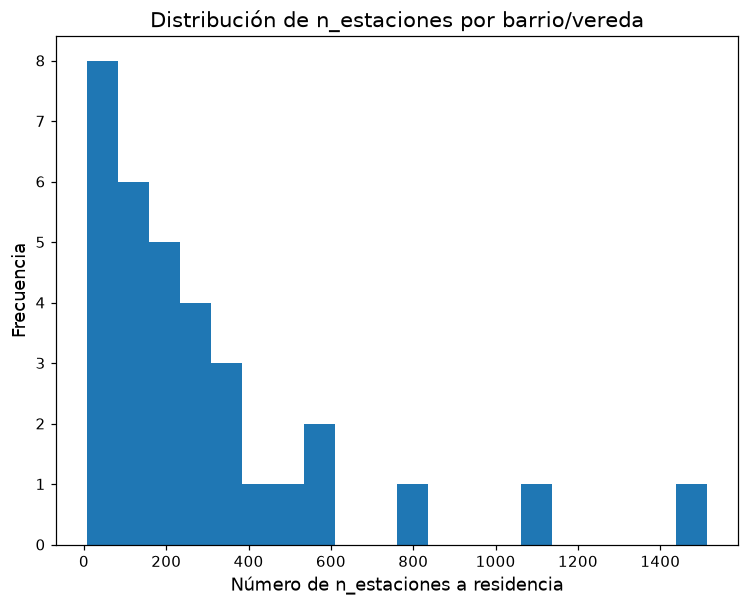

In [47]:
# Histograma del número de n_estaciones por barrio/vereda
ax = deptos["n_estaciones"].plot.hist(bins=20)
ax.set_xlabel("Número de n_estaciones a residencia")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de n_estaciones por barrio/vereda")
plt.show()

## 3. Mapas coropléticos de hurtos por barrio/vereda


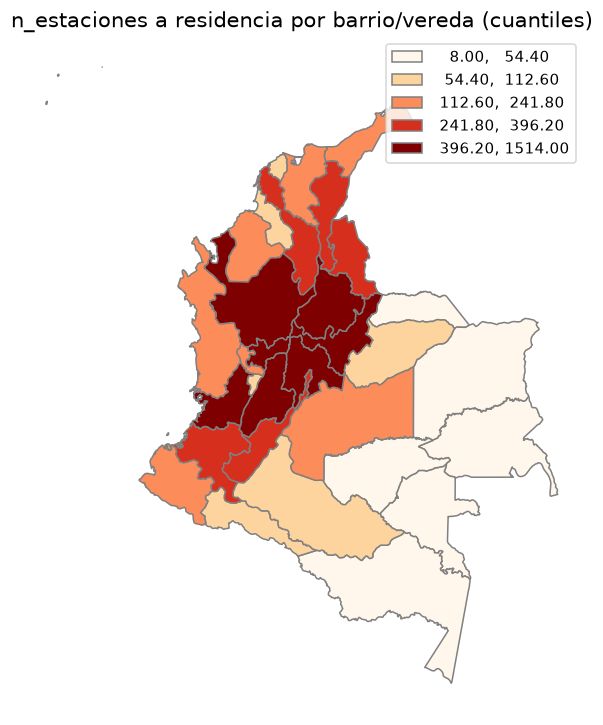

In [48]:
ax = deptos.plot(
    column="n_estaciones",
    cmap="OrRd",
    scheme="Quantiles",
    k=5,
    legend=True,
    edgecolor="gray",
    figsize=(10, 8)
)
ax.set_title("n_estaciones a residencia por barrio/vereda (cuantiles)", fontsize=14)
ax.axis("off")
plt.show()

## 4. Autocorrelación espacial global

In [49]:
# Construir matriz de pesos espaciales (contigüidad Reina)
wq = Queen.from_dataframe(deptos)
wq.transform = "R"  # Convierte los pesos de cada fila en proporciones que suman 1 - row-standardization -garantizando que el spatial lag sea un promedio comparativo entre unidades

print("Número de unidades:", wq.n)
print("Número total de vecinos:", wq.s0)

('WARNING: ', 20, ' is an island (no neighbors)')
Número de unidades: 33
Número total de vecinos: 31.999999999999993


### Con N_estaciones

In [50]:
# Calcular Índice de Moran global para el número de n_estaciones
y = deptos["n_estaciones"].values
moran_global = Moran(y, wq)

print(f"I de Moran: {moran_global.I:.4f}")
print(f"p-valor (permutaciones): {moran_global.p_sim:.4f}")

I de Moran: 0.1713
p-valor (permutaciones): 0.0380


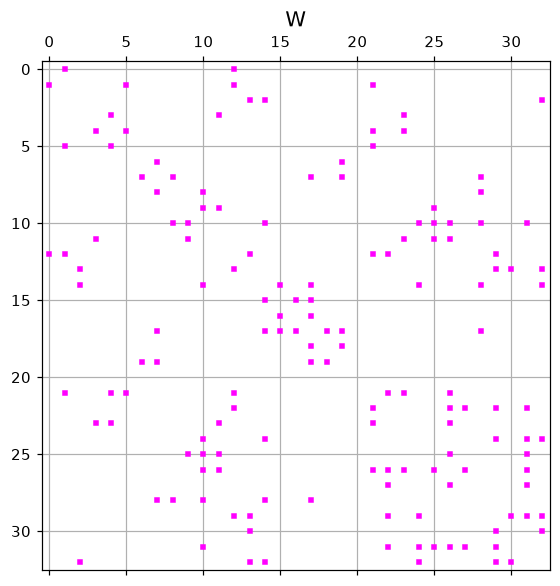

In [51]:
# Graficar la estructura de ocupación
plt.figure(figsize=(6, 6))
plt.spy(moran_global.w.to_sparse(), markersize=3, color='magenta')
plt.grid()

plt.title("W")
plt.show()

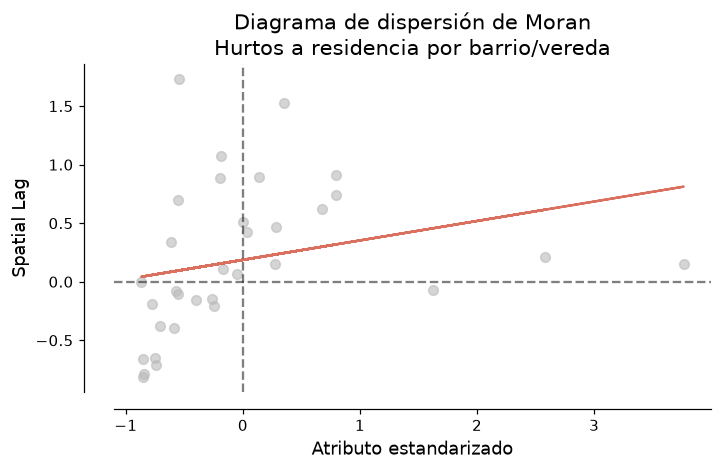

In [52]:
# Diagrama de dispersión de Moran
from splot.esda import moran_scatterplot

fig, ax = moran_scatterplot(moran_global, aspect_equal=True)
ax.set_title("Diagrama de dispersión de Moran\nHurtos a residencia por barrio/vereda")
plt.xlabel("Atributo estandarizado")
plt.show()

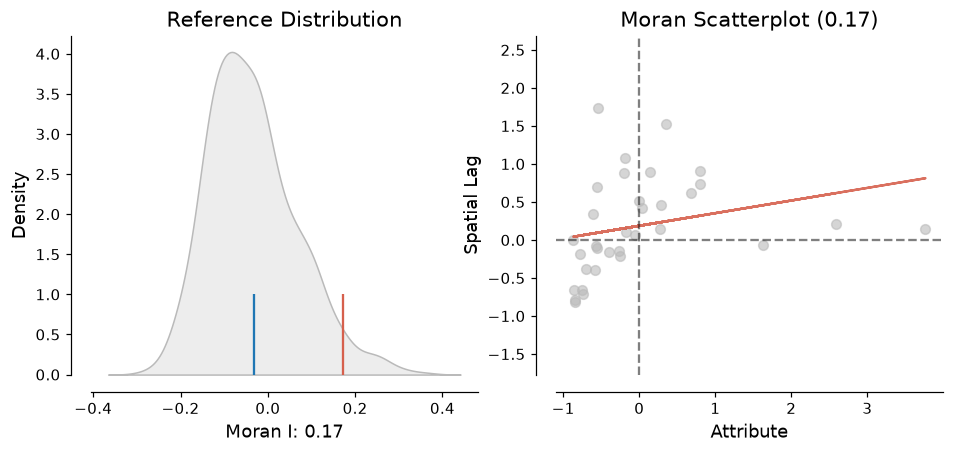

In [53]:
plot_moran(moran_global)
plt.show()

### Con Log(N_estaciones)

In [54]:
# Calcular Índice de Moran global para el número de n_estaciones
y = deptos["log_n_estaciones"].values
moran_global = Moran(y, wq)

print(f"I de Moran: {moran_global.I:.4f}")
print(f"p-valor (permutaciones): {moran_global.p_sim:.4f}")

I de Moran: 0.5131
p-valor (permutaciones): 0.0010


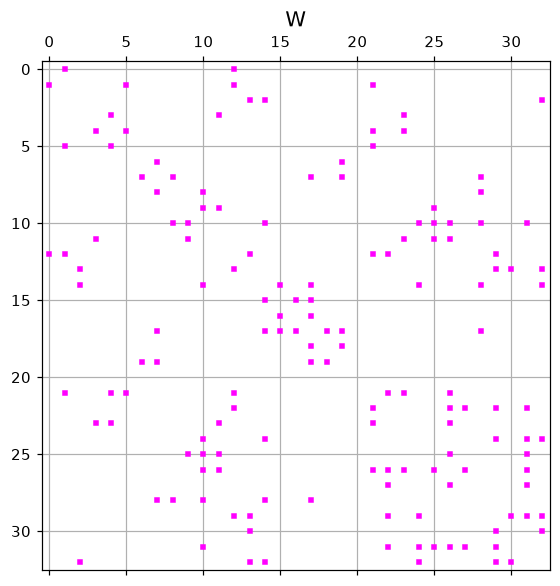

In [55]:
# Graficar la estructura de ocupación
plt.figure(figsize=(6, 6))
plt.spy(moran_global.w.to_sparse(), markersize=3, color='magenta')
plt.grid()

plt.title("W")
plt.show()

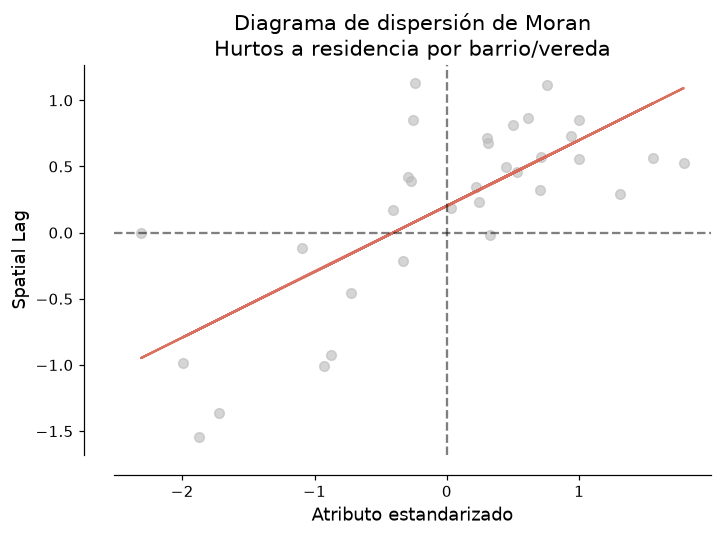

In [56]:
# Diagrama de dispersión de Moran
from splot.esda import moran_scatterplot

fig, ax = moran_scatterplot(moran_global, aspect_equal=True)
ax.set_title("Diagrama de dispersión de Moran\nHurtos a residencia por barrio/vereda")
plt.xlabel("Atributo estandarizado")
plt.show()

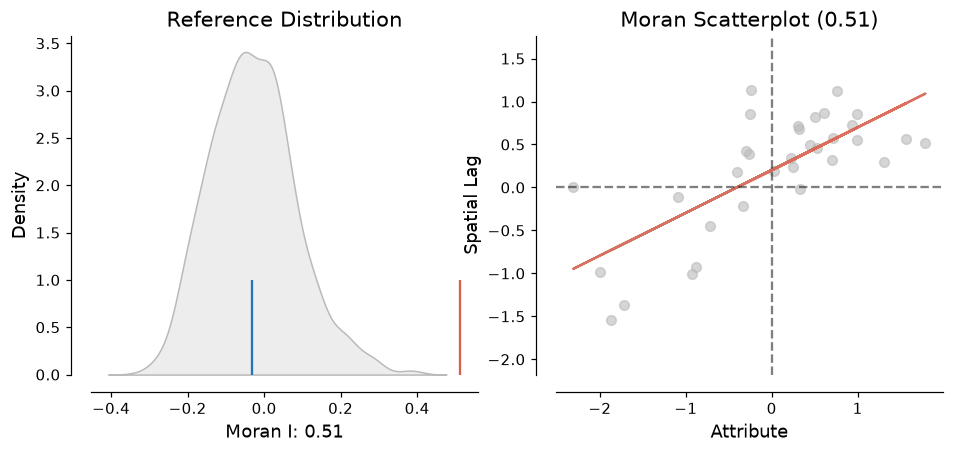

In [57]:
plot_moran(moran_global)
plt.show()

## 5. Autocorrelación espacial local (LISA)


In [58]:
# Cálculo de Moran Local
moran_local = Moran_Local(y, wq)

# Añadir resultados al GeoDataFrame
deptos["Is"] = moran_local.Is          # valor del estadístico local
deptos["p_sim"] = moran_local.p_sim    # p-valor por permutaciones
deptos["q"] = moran_local.q            # cuadrante (1:AA, 2:BA, 3:BB, 4:AB)

deptos[["name", "n_estaciones", "Is", "p_sim", "q"]].head()

,name,n_estaciones,Is,p_sim,q
0,Nariño,160,0.005861,0.433,1
1,Putumayo,100,0.069773,0.299,3
2,Chocó,113,-0.263259,0.012,2
3,Guainía,14,2.807405,0.001,3
4,Vaupés,17,2.278907,0.001,3


<Axes: xlabel='Is', ylabel='Density'>

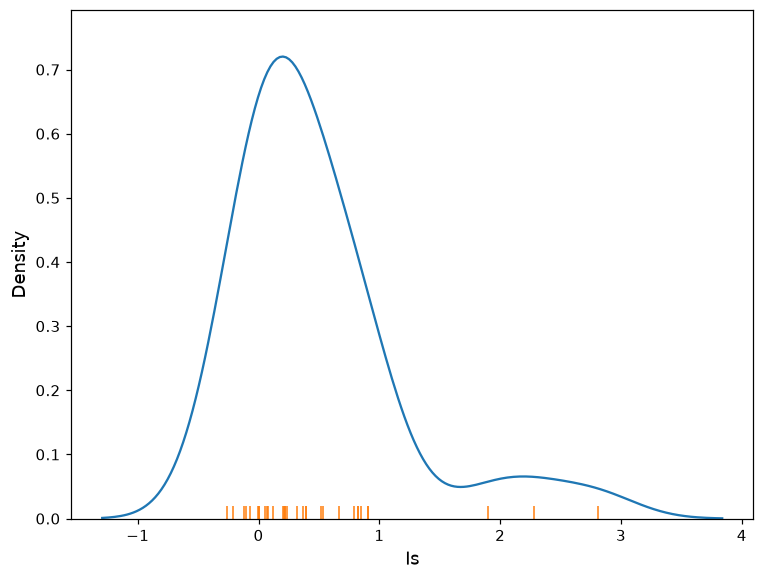

In [59]:
ax = sns.kdeplot(deptos.Is)
# Add one small bar (rug) for each observation
# along horizontal axis
sns.rugplot(deptos.Is, ax=ax)

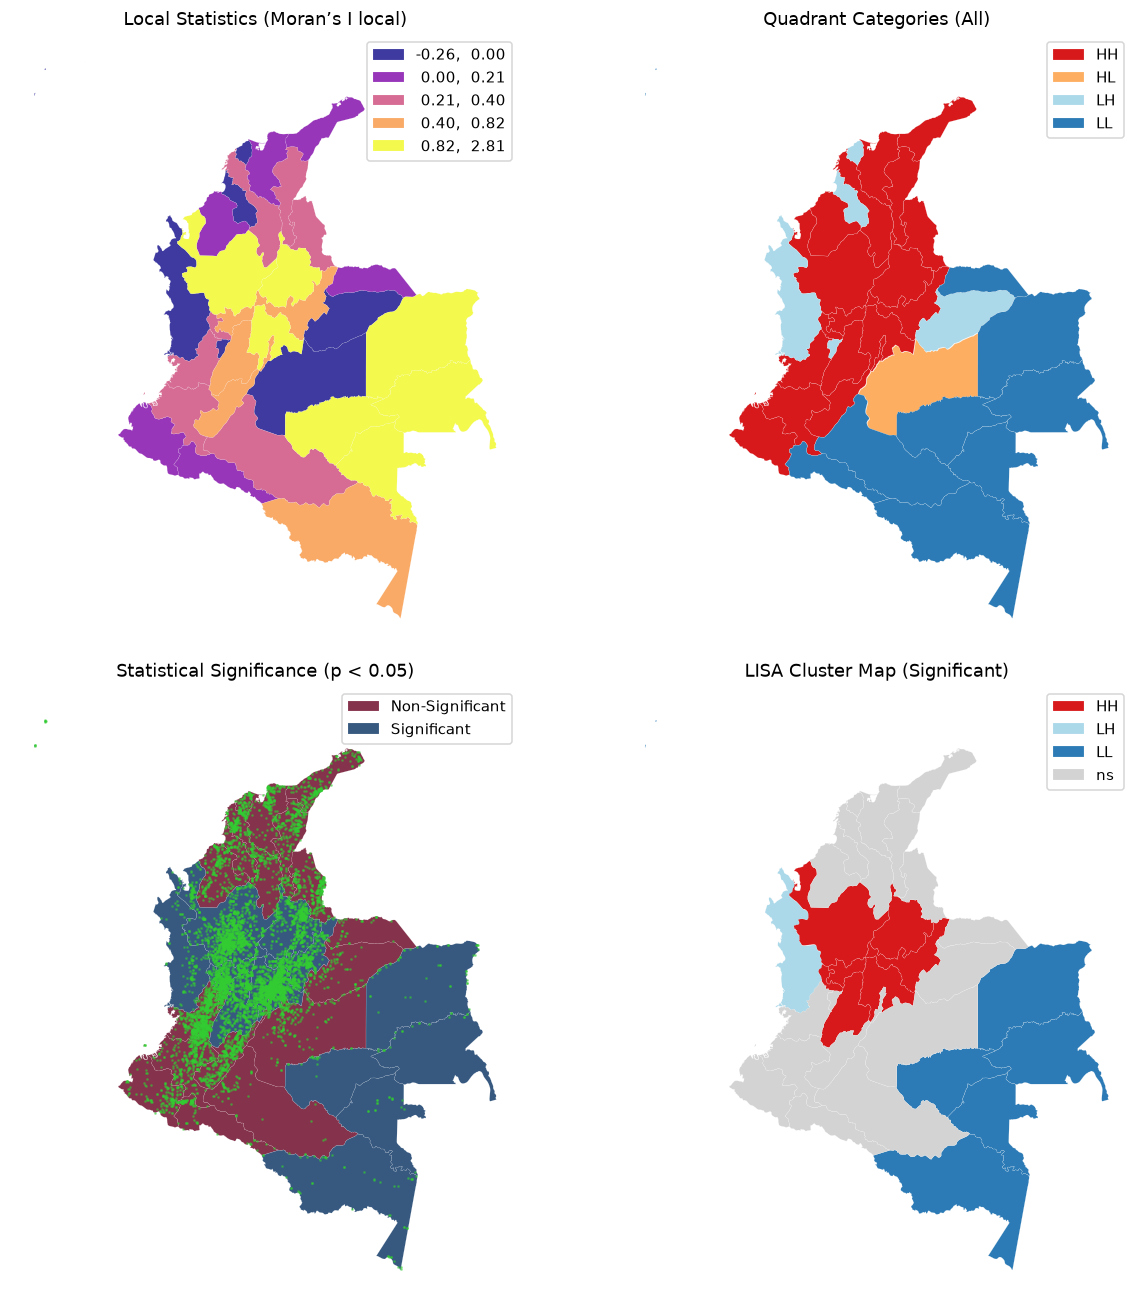

In [60]:
# Crear figura
f, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))
axs = axs.flatten()

# Mapa de valores del estadístico local
ax = axs[0]
deptos.plot(
    column="Is",
    cmap="plasma",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.1,
    alpha=0.8,
    legend=True,
    ax=ax,
)
ax.set_title("Local Statistics (Moran’s I local)", fontsize=12)
ax.axis("off")

# Cuadrantes del diagrama de dispersión (sin filtrar por p)
ax = axs[1]
lisa_cluster(moran_local, deptos, p=1, ax=ax)
ax.set_title("Quadrant Categories (All)", fontsize=12)
ax.axis("off")

# Significancia estadística
ax = axs[2]
deptos["signif"] = (
    pd.Series((moran_local.p_sim < 0.05).astype(int), index=deptos.index)
    .map({1: "Significant", 0: "Non-Significant"})
)
deptos.plot(
    column="signif",
    categorical=True,
    cmap="RdBu",
    linewidth=0.1,
    edgecolor="white",
    legend=True,
    alpha = 0.8,
    ax=ax,
)
#ax = deptos.plot(color="#F7F7F7", edgecolor="#BBBBBB", linewidth=0.4, figsize=(6.5, 6.5))
estaciones.plot(ax=ax, color="limegreen", markersize=0.7, alpha=0.45)
ax.set_title(f"{len(estaciones)} estaciones a residencia (2003–2022) como puntos");

ax.set_title("Statistical Significance (p < 0.05)", fontsize=12)
ax.axis("off")

# Mapa LISA (solo observaciones significativas)
ax = axs[3]
lisa_cluster(moran_local, deptos, p=0.05, ax=ax)
ax.set_title("LISA Cluster Map (Significant)", fontsize=12)
ax.axis("off")

# Ajuste final
f.tight_layout()
plt.show()

# Analisis bivariado

## Preparación de los datos

# Datos que no tenian latitud ni longitud

In [61]:
emergencias = [
    "AVENIDA TORRENCIAL",
    "CRECIENTE SUBITA",
    "INUNDACION",
    "MOVIMIENTO EN MASA",
    "EROSION",
    "SEQUIA",
    "DESABASTECIMIENTO DE AGUA",
    "ACCIDENTE FLUVIAL",
    "EROSION COSTERA",
]

In [62]:
eventos = pd.read_csv("ourdata/Emergencias_UNGRD_V2_20260930.csv")
eventos = eventos[eventos["EVENTO"].isin(emergencias)]
eventos.info()

<class 'pandas.DataFrame'>
Index: 4716 entries, 0 to 13011
Data columns (total 61 columns):
 #   Column                                                               Non-Null Count  Dtype
---  ------                                                               --------------  -----
 0   FECHA                                                                4716 non-null   str  
 1   DEPARTAMENTO                                                         4716 non-null   str  
 2   MUNICIPIO                                                            4716 non-null   str  
 3   EVENTO                                                               4716 non-null   str  
 4   CODIFICACIÓN SEGUN DIVIPOLA                                          4716 non-null   str  
 5   COORDENADAS                                                          4716 non-null   str  
 6   FALLECIDOS                                                           4716 non-null   int64
 7   HERIDOS                                

In [63]:
eventos.groupby("DEPARTAMENTO").head()

,FECHA,DEPARTAMENTO,MUNICIPIO,EVENTO,CODIFICACIÓN SEGUN DIVIPOLA,COORDENADAS,FALLECIDOS,HERIDOS,DESAPARECIDOS,PERSONAS,...,VALOR - AGUA Y SANEAMIENTO BASICO,ACCIONES ESPECIFICAS - OBRAS DE EMERGENCIA - \nBANCO DE MAQUINARIA,VALOR - OBRAS DE EMERGENCIA - \nBANCO DE MAQUINARIA,DESCRIPCION - OTROS APOYOS,VALOR - OTROS APOYOS,No DECRETO DE CALAMIDAD PUBLICA,INICIO DECRETO DE CALAMIDAD PUBLICA,COMENTARIOS,CODIGO EMERGENCIA,VALOR - APOYO TOTAL DEL FNGRD
0,2025 Jan 01 12:00:00 AM,CESAR,BECERRIL,AVENIDA TORRENCIAL,"20,045",0,0,0,0,32,...,$ - 0,No Registra,$ - 0,No Registra,$ - 0,0,No Registra,"CDGRD CESAR INFORMA, MUNICIPIO: BECERRIL - ZON...",1,$ 0.00
5,2025 Jan 01 12:00:00 AM,META,PUERTO LOPEZ,CRECIENTE SUBITA,"20,050",0,1,0,0,0,...,$ - 0,No Registra,$ - 0,No Registra,$ - 0,0,No Registra,"CDGRD META, INFORMA\nMUNICIPIO PUERTO LÓPEZ, V...",6,$ 0.00
6,2025 Jan 01 12:00:00 AM,NARIÑO,ARBOLEDA,MOVIMIENTO EN MASA,"20,051",0,0,0,0,0,...,$ - 0,No Registra,$ - 0,No Registra,$ - 0,0,No Registra,"CDGRD NARIÑO, INFORMA\nMUNICIPIO ARBOLEDA, VÍA...",7,$ 0.00
8,2025 Jan 01 12:00:00 AM,TOLIMA,RIOBLANCO,MOVIMIENTO EN MASA,"20,053",0,0,0,0,5,...,$ - 0,No Registra,$ - 0,No Registra,$ - 0,0,No Registra,"CDGRD TOLIMA INFORMA, MUNICIPIO: RÍO BLANCO - ...",9,$ 0.00
9,2025 Jan 01 12:00:00 AM,VALLE DEL CAUCA,CALI,CRECIENTE SUBITA,"20,054",0,1,0,0,0,...,$ - 0,No Registra,$ - 0,No Registra,$ - 0,0,No Registra,CDGRD VALLE DEL CAUCA INFORMA: MUNICIPIO: CALI...,10,$ 0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10237,2025 Jun 23 12:00:00 AM,ATLANTICO,LURUACO,INUNDACION,"8,421",0,0,0,0,360,...,$ - 0,No Registra,$ - 0,No Registra,$ - 0,No Registra,No Registra,"CDGRD ATLÁNTICO INFORMA:\nMUNICIPIO: LURUACO, ...","3,669",$ 0.00
11008,2025 Aug 07 12:00:00 AM,VAUPES,MITU,INUNDACION,"97,001",0,0,0,0,30,...,$ - 0,No Registra,$ - 0,No Registra,$ - 0,No Registra,No Registra,DCC Y CDGRD VAUPÉS INFORMAN: MUNICIPIO: MITÚ -...,"4,467",$ 0.00
11538,2025 Apr 05 12:00:00 AM,GUAINIA,INIRIDA,INUNDACION,"22,412",0,0,0,0,12,...,$ - 0,No Registra,$ - 0,No Registra,$ - 0,0,No Registra,"CITEL DCC INFORMA:, MUNICIPIO: INÍRIDA, GUAINÍ...","5,001","$ 4,666,044,124.00"
11546,2025 Sep 08 12:00:00 AM,ATLANTICO,BARRANQUILLA,CRECIENTE SUBITA,"8,001",0,0,0,0,12,...,$ - 0,No Registra,$ - 0,No Registra,$ - 0,No Registra,No Registra,CDGRD ATLÁNTICO INFORMA: MUNICIPIO: BARRANQUIL...,"5,009",$ 0.00


# Precipitaciones

In [94]:
precipitacion = pd.read_csv("ourdata/Precipitación_20261001.csv")
display(precipitacion.head())
precipitacion.info()

,CodigoEstacion,CodigoSensor,FechaObservacion,ValorObservado,NombreEstacion,Departamento,Municipio,ZonaHidrografica,Latitud,Longitud,DescripcionSensor,UnidadMedida
0,16027060,240.0,2020 Sep 30 08:20:00 PM,0.0,PUERTO LEON - AUT,NORTE DE SANTANDER,PUERTO SANTANDER,CATATUMBO,8.350278,-72.434722,Precipitacion,mm
1,26125508,240.0,2020 Sep 30 07:00:00 AM,0.0,LACATALINA - AUT,RISARALDA,PEREIRA,CAUCA,4.747500,-75.738056,Precipitacion,mm
2,2401500052,240.0,2020 Sep 30 12:20:00 PM,0.0,PUENTE GUILLERMO - AUT,SANTANDER,PUENTE NACIONAL,SOGAMOSO,5.796417,-73.726667,Precipitacion,mm
3,24037080,240.0,2020 Sep 30 03:40:00 PM,0.0,LA GRUTA - AUT,BOYACÁ,PESCA,SOGAMOSO,5.566972,-73.046722,Precipitacion,mm
4,26075501,240.0,2020 Sep 30 07:10:00 PM,0.0,FLORIDA - AUT,VALLE DEL CAUCA,FLORIDA,CAUCA,3.291469,-76.177358,Precipitacion,mm


<class 'pandas.DataFrame'>
RangeIndex: 3899646 entries, 0 to 3899645
Data columns (total 12 columns):
 #   Column             Dtype  
---  ------             -----  
 0   CodigoEstacion     object 
 1   CodigoSensor       float64
 2   FechaObservacion   str    
 3   ValorObservado     float64
 4   NombreEstacion     str    
 5   Departamento       str    
 6   Municipio          str    
 7   ZonaHidrografica   str    
 8   Latitud            float64
 9   Longitud           float64
 10  DescripcionSensor  str    
 11  UnidadMedida       str    
dtypes: float64(4), object(1), str(7)
memory usage: 669.6+ MB


In [95]:
vals, freq = np.unique(precipitacion["ValorObservado"], return_counts=True)

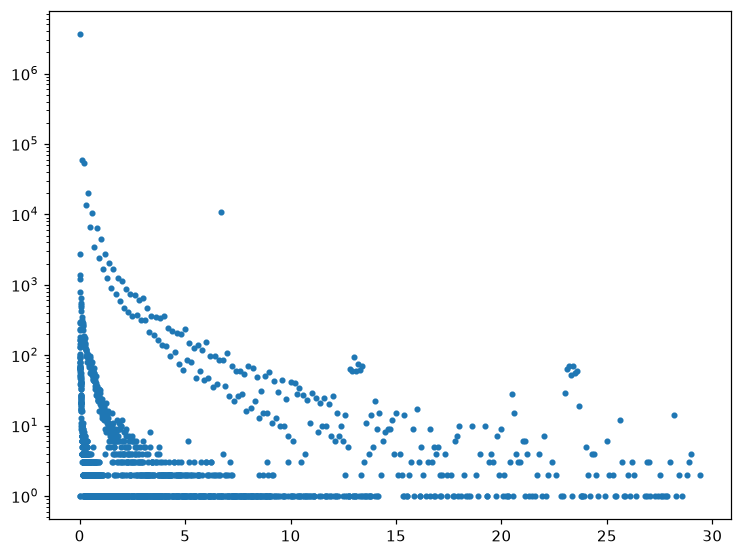

In [96]:
plt.plot(vals, freq, ".")
plt.yscale("log")

In [146]:
precipitacion = gpd.GeoDataFrame(precipitacion, geometry=gpd.points_from_xy(precipitacion.Longitud, precipitacion.Latitud), crs=4326).to_crs(deptos.crs)

filas del CSV: 9727 | eventos únicos con coordenada: 3899646 | dentro de los deptos urbanos: 3879112


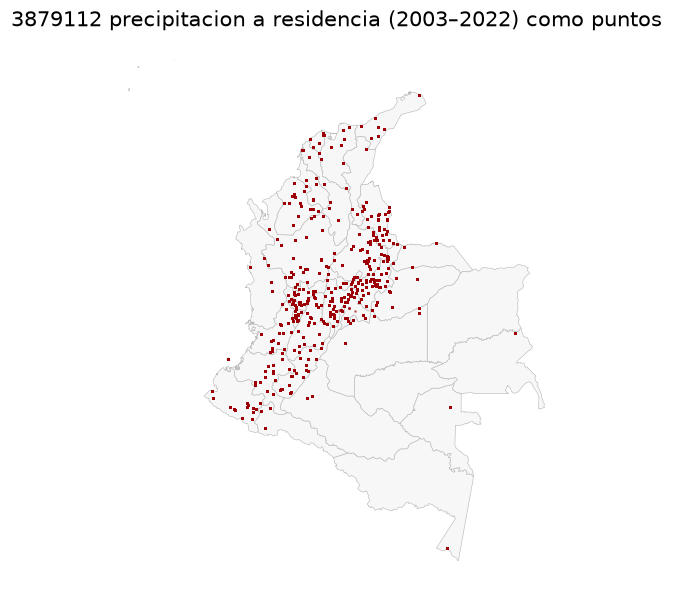

In [99]:
precipitacion = precipitacion[precipitacion.within(deptos.union_all())]
print("filas del CSV:", len(h), "| eventos únicos con coordenada:", len(eventos), "| dentro de los deptos urbanos:", len(precipitacion))
ax = deptos.plot(color="#F7F7F7", edgecolor="#BBBBBB", linewidth=0.4, figsize=(6.5, 6.5))
precipitacion.plot(ax=ax, color=ROJO, markersize=0.7, alpha=0.45); ax.set_axis_off()
ax.set_title(f"{len(precipitacion)} precipitacion a residencia (2003–2022) como puntos");

In [116]:
union = gpd.sjoin(precipitacion, deptos[["name", "geometry"]], how="inner", predicate="within")
conteo = union.groupby("name")["ValorObservado"].mean()
deptos["n_precipitacion"] = deptos.name.map(conteo).fillna(0)#.astype(int)        # la tasa: eventos por km²
#deptos["log_n_precipitacion"] = np.log10(deptos["n_precipitacion"])

count    33.0
mean      0.1
std       0.2
min       0.0
25%       0.0
50%       0.0
75%       0.1
max       1.0
Name: n_precipitacion, dtype: float64
asimetría: 5.5


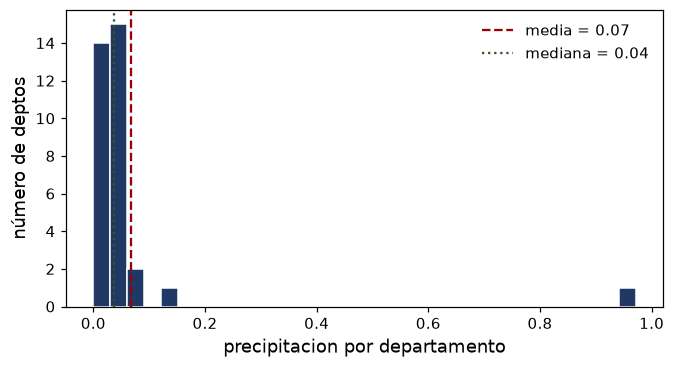

In [152]:
y = deptos.n_precipitacion.values
print(deptos.n_precipitacion.describe().round(1)); print("asimetría:", round(pd.Series(y).skew(), 2))
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(y, bins=32, color=AZUL, edgecolor="white")
ax.axvline(y.mean(), color=ROJO, ls="--", label=f"media = {y.mean():.2f}"); ax.axvline(np.median(y), color="#375623", ls=":", label=f"mediana = {np.median(y):.2f}")
ax.set_xlabel("precipitacion por departamento"); ax.set_ylabel("número de deptos"); ax.legend(frameon=False);

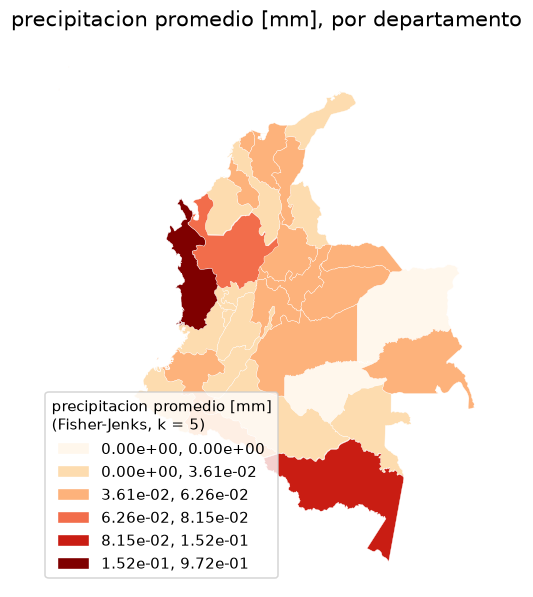

In [121]:
fig, ax = plt.subplots(figsize=(7, 6.5))
deptos.plot(column="n_precipitacion", scheme="FisherJenks", k=6, cmap="OrRd", edgecolor="white", linewidth=0.25, ax=ax,
             legend=True, legend_kwds={"title": "precipitacion promedio [mm]\n(Fisher-Jenks, k = 5)", "loc": "lower left", "fmt": "{:.2e}"})
ax.set_axis_off(); ax.set_title("precipitacion promedio [mm], por departamento");

## Correlación bivariada global

In [131]:
from esda.moran import Moran_Local_BV
from esda import Moran_BV

In [132]:
# Variables para análisis bivariado
y1 = deptos["log_n_estaciones"].values
y2 = deptos["n_precipitacion"].values

In [133]:
# LISA Bivariado
ml_bv = Moran_Local_BV(y1, y2, wq)

# Agregar resultados al GeoDataFrame
deptos["I_bv"] = ml_bv.Is          # índice local
deptos["p_bv"] = ml_bv.p_sim       # p-valores
deptos["q_bv"] = ml_bv.q           # cuadrantes: 1-HH, 2-LH, 3-LL, 4-HL

In [134]:
moran_bv = Moran_BV(y1, y2, wq)

print("Índice Moran Bivariado:", moran_bv.I)
print("p-valor:", moran_bv.p_sim)

Índice Moran Bivariado: 0.09096667937007813
p-valor: 0.225


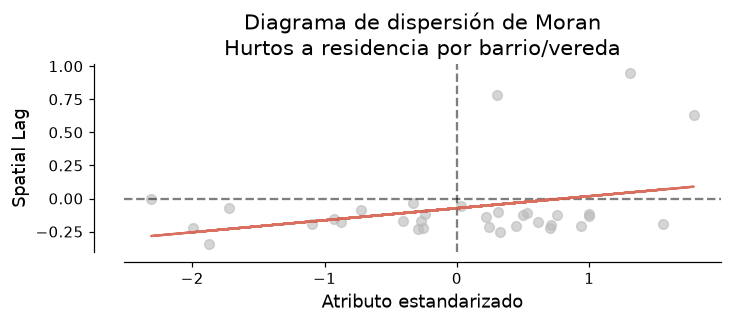

In [138]:
# Diagrama de dispersión de Moran
from splot.esda import moran_scatterplot

fig, ax = moran_scatterplot(ml_bv, aspect_equal=True)
ax.set_title("Diagrama de dispersión de Moran\nN estaciones y precipitaciones")
plt.xlabel("Atributo estandarizado")
plt.show()

<Axes: xlabel='I_bv', ylabel='Density'>

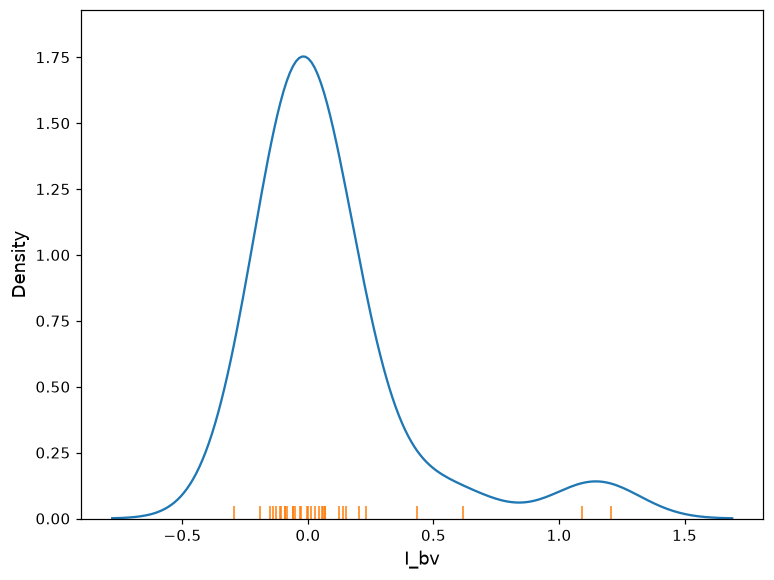

In [140]:
ax = sns.kdeplot(deptos.I_bv)
# Add one small bar (rug) for each observation
# along horizontal axI_bv
sns.rugplot(deptos.I_bv, ax=ax)

## Correlación bivariada local

In [136]:
# LISA Bivariado
ml_bv = Moran_Local_BV(y1, y2, wq)

# Agregar resultados al GeoDataFrame
deptos["I_bv"] = ml_bv.Is          # índice local
deptos["p_bv"] = ml_bv.p_sim       # p-valores
deptos["q_bv"] = ml_bv.q           # cuadrantes: 1-HH, 2-LH, 3-LL, 4-HL

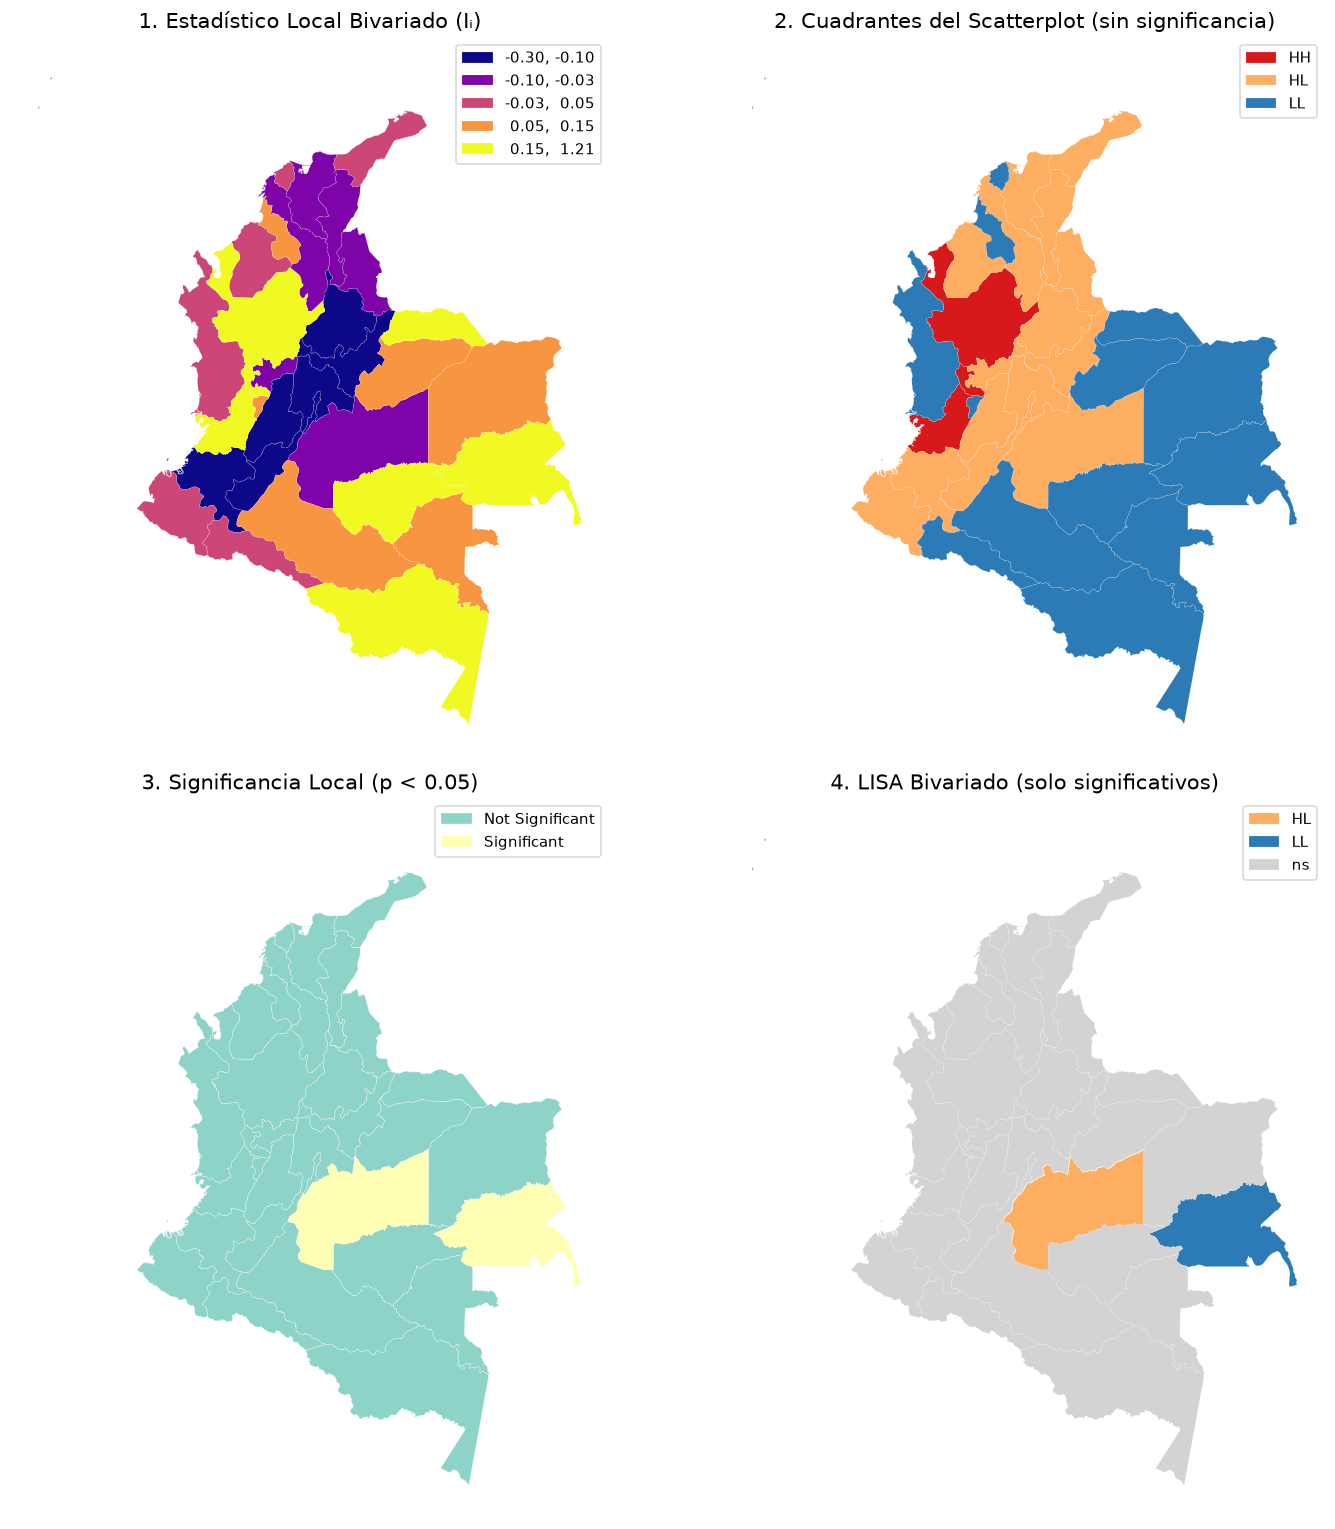

In [137]:
# Crear figura con 4 subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 14))
axs = axs.flatten()

# 1. Mapa del estadístico local bivariado (I_bv)
deptos.plot(
    column="I_bv",
    cmap="plasma",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.1,
    legend=True,
    ax=axs[0]
)
axs[0].set_title("1. Estadístico Local Bivariado (Iᵢ)", fontsize=14)
axs[0].axis("off")

# 2. Mapa de cuadrantes (sin evaluar significancia)
lisa_cluster(ml_bv, deptos, p=1, ax=axs[1])  # p=1 → todos los quadrantes
axs[1].set_title("2. Cuadrantes del Scatterplot (sin significancia)", fontsize=14)
axs[1].axis("off")

# 3. Mapa de significancia local (p < 0.05)
deptos["sig_bv"] = (deptos["p_bv"] < 0.05).map({
    True: "Significant", False: "Not Significant"
})

deptos.plot(
    column="sig_bv",
    categorical=True,
    cmap="Set3",
    k=2,
    legend=True,
    edgecolor="white",
    linewidth=0.2,
    ax=axs[2]
)
axs[2].set_title("3. Significancia Local (p < 0.05)", fontsize=14)
axs[2].axis("off")

# 4. Mapa LISA Bivariado (solo clústeres significativos)
lisa_cluster(ml_bv, deptos, p=0.05, ax=axs[3])
axs[3].set_title("4. LISA Bivariado (solo significativos)", fontsize=14)
axs[3].axis("off")

# Ajustar espacios
plt.tight_layout()
plt.show()

# Nivel instantaneo de rios

In [141]:
nivel = pd.read_csv("ourdata/Nivel_Instantáneo_del_Rio_20261001.csv")
display(nivel.head())
nivel.info()

,CodigoEstacion,CodigoSensor,FechaObservacion,ValorObservado,NombreEstacion,Departamento,Municipio,ZonaHidrografica,Latitud,Longitud,DescripcionSensor,UnidadMedida
0,22057010,230.0,2011 Sep 17 08:00:00 PM,2.740,PIEDRAS DE COBRE - AUT,TOLIMA,SALDAÑA,SALDAÑA,3.908389,-75.103278,Nivel Instantaneo,mt
1,15017030,230.0,2019 Jul 13 09:00:00 PM,38.000,MINCA - AUT,MAGDALENA,SANTA MARTA,CARIBE - GUAJIRA,11.158917,-74.122917,Nivel Instantaneo,mt
2,26157200,230.0,2011 May 20 04:45:00 AM,0.460,SIETECUERALES - AUT,CALDAS,VILLAMARIA,CAUCA,4.860222,-75.374639,Nivel Instantaneo,mt
3,24017702,230.0,2019 Aug 26 10:30:00 PM,49.205,EL BOQUERÓN - AUT,CUNDINAMARCA,LENGUAZAQUE,ALTO MAGDALENA,5.198000,-73.805000,Nivel Instantaneo,mt
4,29037080,230.0,2013 Aug 09 02:00:00 PM,6.030,GAMBOTE CANAL DEL DIQUE-DESINSTALADA,BOLÍVAR,ARJONA,BAJO MAGDALENA,10.162000,-75.299000,Nivel Instantaneo,mt


<class 'pandas.DataFrame'>
RangeIndex: 3399902 entries, 0 to 3399901
Data columns (total 12 columns):
 #   Column             Dtype  
---  ------             -----  
 0   CodigoEstacion     object 
 1   CodigoSensor       float64
 2   FechaObservacion   str    
 3   ValorObservado     float64
 4   NombreEstacion     str    
 5   Departamento       str    
 6   Municipio          str    
 7   ZonaHidrografica   str    
 8   Latitud            float64
 9   Longitud           float64
 10  DescripcionSensor  str    
 11  UnidadMedida       str    
dtypes: float64(4), object(1), str(7)
memory usage: 606.0+ MB


In [147]:
vals, freq = np.unique(nivel["ValorObservado"], return_counts=True)

In [142]:
vals[freq == freq.max()]

array([0.])

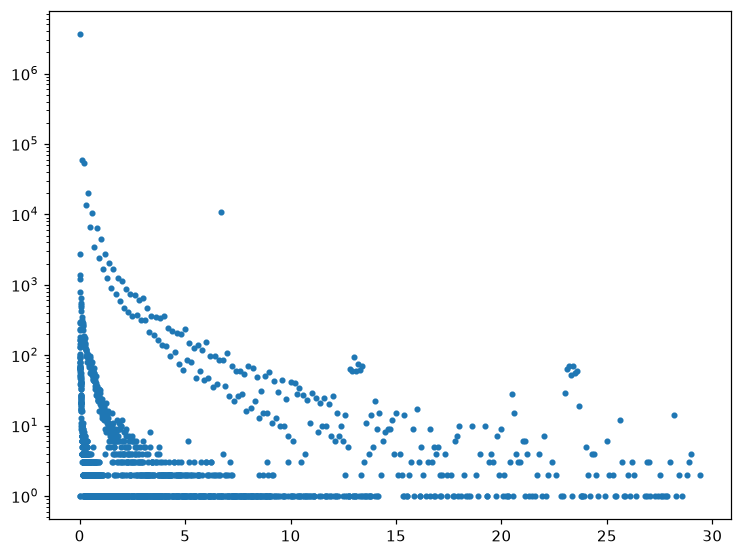

In [143]:
plt.plot(vals, freq, ".")
plt.yscale("log")

In [148]:
nivel = gpd.GeoDataFrame(nivel, geometry=gpd.points_from_xy(nivel.Longitud, nivel.Latitud), crs=4326).to_crs(deptos.crs)

filas del CSV: 9727 | eventos únicos con coordenada: 3899646 | dentro de los deptos urbanos: 3341522


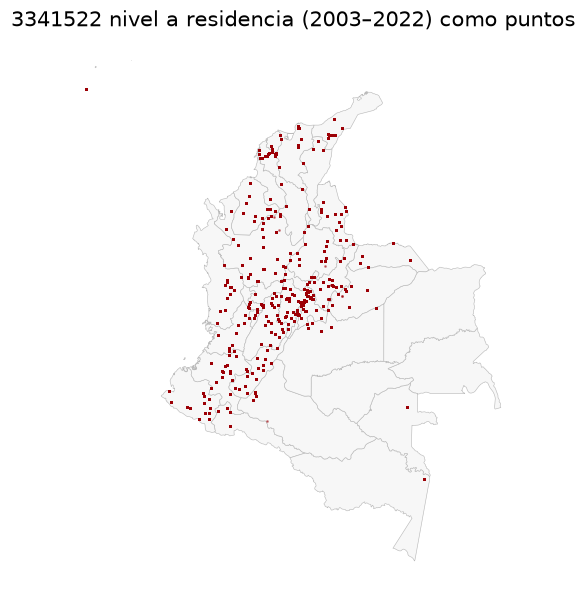

In [149]:
nivel = nivel[nivel.within(deptos.union_all())]
print("filas del CSV:", len(h), "| eventos únicos con coordenada:", len(eventos), "| dentro de los deptos urbanos:", len(nivel))
ax = deptos.plot(color="#F7F7F7", edgecolor="#BBBBBB", linewidth=0.4, figsize=(6.5, 6.5))
nivel.plot(ax=ax, color=ROJO, markersize=0.7, alpha=0.45); ax.set_axis_off()
ax.set_title(f"{len(nivel)} nivel del rio como puntos");

In [150]:
union = gpd.sjoin(nivel, deptos[["name", "geometry"]], how="inner", predicate="within")
conteo = union.groupby("name")["ValorObservado"].mean()
deptos["n_nivel"] = deptos.name.map(conteo).fillna(0)#.astype(int)        # la tasa: eventos por km²
#deptos["log_n_nivel"] = np.log10(deptos["n_nivel"])

count    33.0
mean     15.8
std      16.2
min       0.0
25%       3.9
50%      12.5
75%      22.2
max      67.8
Name: n_nivel, dtype: float64
asimetría: 1.72


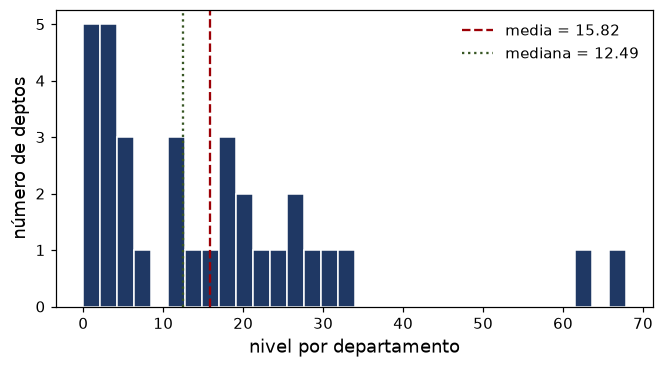

In [151]:
y = deptos.n_nivel.values
print(deptos.n_nivel.describe().round(1)); print("asimetría:", round(pd.Series(y).skew(), 2))
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(y, bins=32, color=AZUL, edgecolor="white")
ax.axvline(y.mean(), color=ROJO, ls="--", label=f"media = {y.mean():.2f}"); ax.axvline(np.median(y), color="#375623", ls=":", label=f"mediana = {np.median(y):.2f}")
ax.set_xlabel("nivel por departamento"); ax.set_ylabel("número de deptos"); ax.legend(frameon=False);

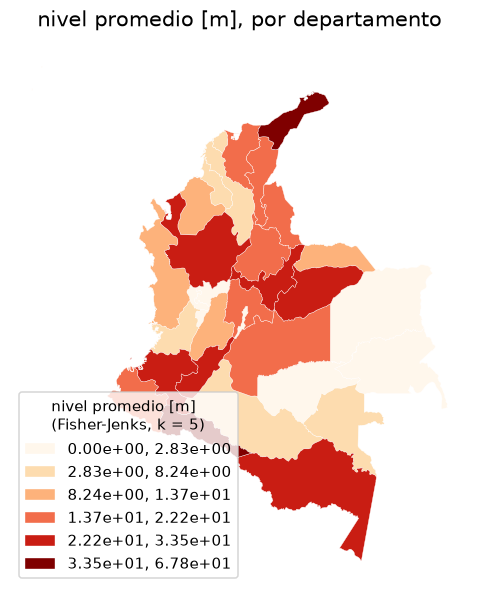

In [155]:
fig, ax = plt.subplots(figsize=(7, 6.5))
deptos.plot(column="n_nivel", scheme="FisherJenks", k=6, cmap="OrRd", edgecolor="white", linewidth=0.25, ax=ax,
             legend=True, legend_kwds={"title": "nivel promedio [m]\n(Fisher-Jenks, k = 5)", "loc": "lower left", "fmt": "{:.2e}"})
ax.set_axis_off(); ax.set_title("nivel promedio [m], por departamento");

## Correlación bivariada global

In [156]:
from esda.moran import Moran_Local_BV
from esda import Moran_BV

In [157]:
# Variables para análisis bivariado
y1 = deptos["log_n_estaciones"].values
y2 = deptos["n_nivel"].values

In [159]:
# LISA Bivariado
ml_bv = Moran_Local_BV(y1, y2, wq)

# Agregar resultados al GeoDataFrame
deptos["I_bv2"] = ml_bv.Is          # índice local
deptos["p_bv2"] = ml_bv.p_sim       # p-valores
deptos["q_bv2"] = ml_bv.q           # cuadrantes: 1-HH, 2-LH, 3-LL, 4-HL

In [160]:
moran_bv = Moran_BV(y1, y2, wq)

print("Índice Moran Bivariado:", moran_bv.I)
print("p-valor:", moran_bv.p_sim)

Índice Moran Bivariado: 0.10516117982554808
p-valor: 0.167


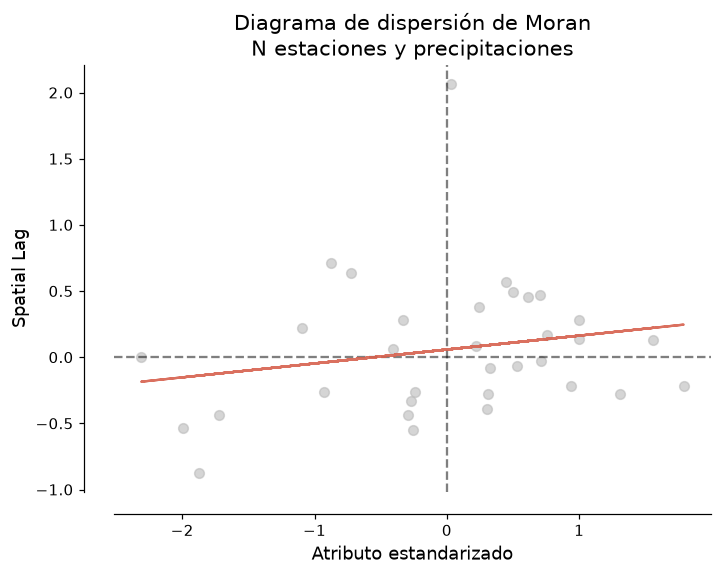

In [161]:
# Diagrama de dispersión de Moran
from splot.esda import moran_scatterplot

fig, ax = moran_scatterplot(ml_bv, aspect_equal=True)
ax.set_title("Diagrama de dispersión de Moran\nN estaciones y precipitaciones")
plt.xlabel("Atributo estandarizado")
plt.show()

<Axes: xlabel='I_bv2', ylabel='Density'>

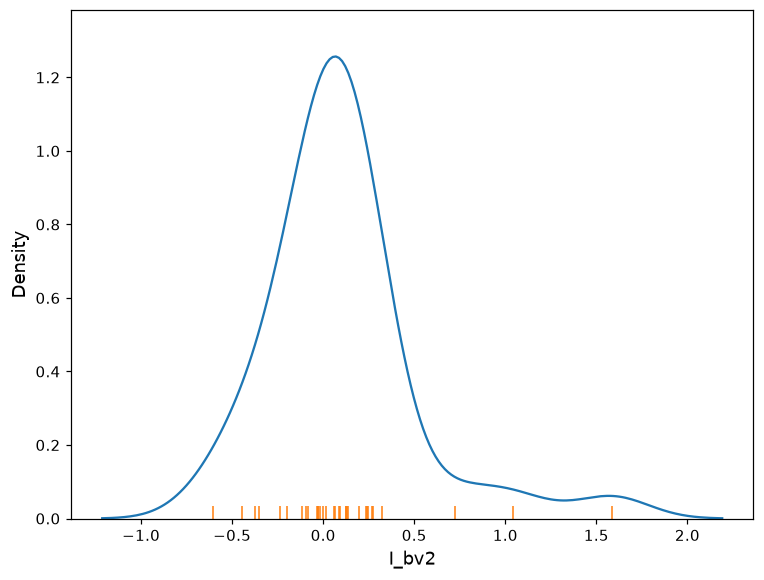

In [162]:
ax = sns.kdeplot(deptos.I_bv2)
# Add one small bar (rug) for each observation
# along horizontal axI_bv
sns.rugplot(deptos.I_bv2, ax=ax)

## Correlación bivariada local

In [163]:
# LISA Bivariado
ml_bv = Moran_Local_BV(y1, y2, wq)

# Agregar resultados al GeoDataFrame
deptos["I_bv2"] = ml_bv.Is          # índice local
deptos["p_bv2"] = ml_bv.p_sim       # p-valores
deptos["q_bv2"] = ml_bv.q           # cuadrantes: 1-HH, 2-LH, 3-LL, 4-HL

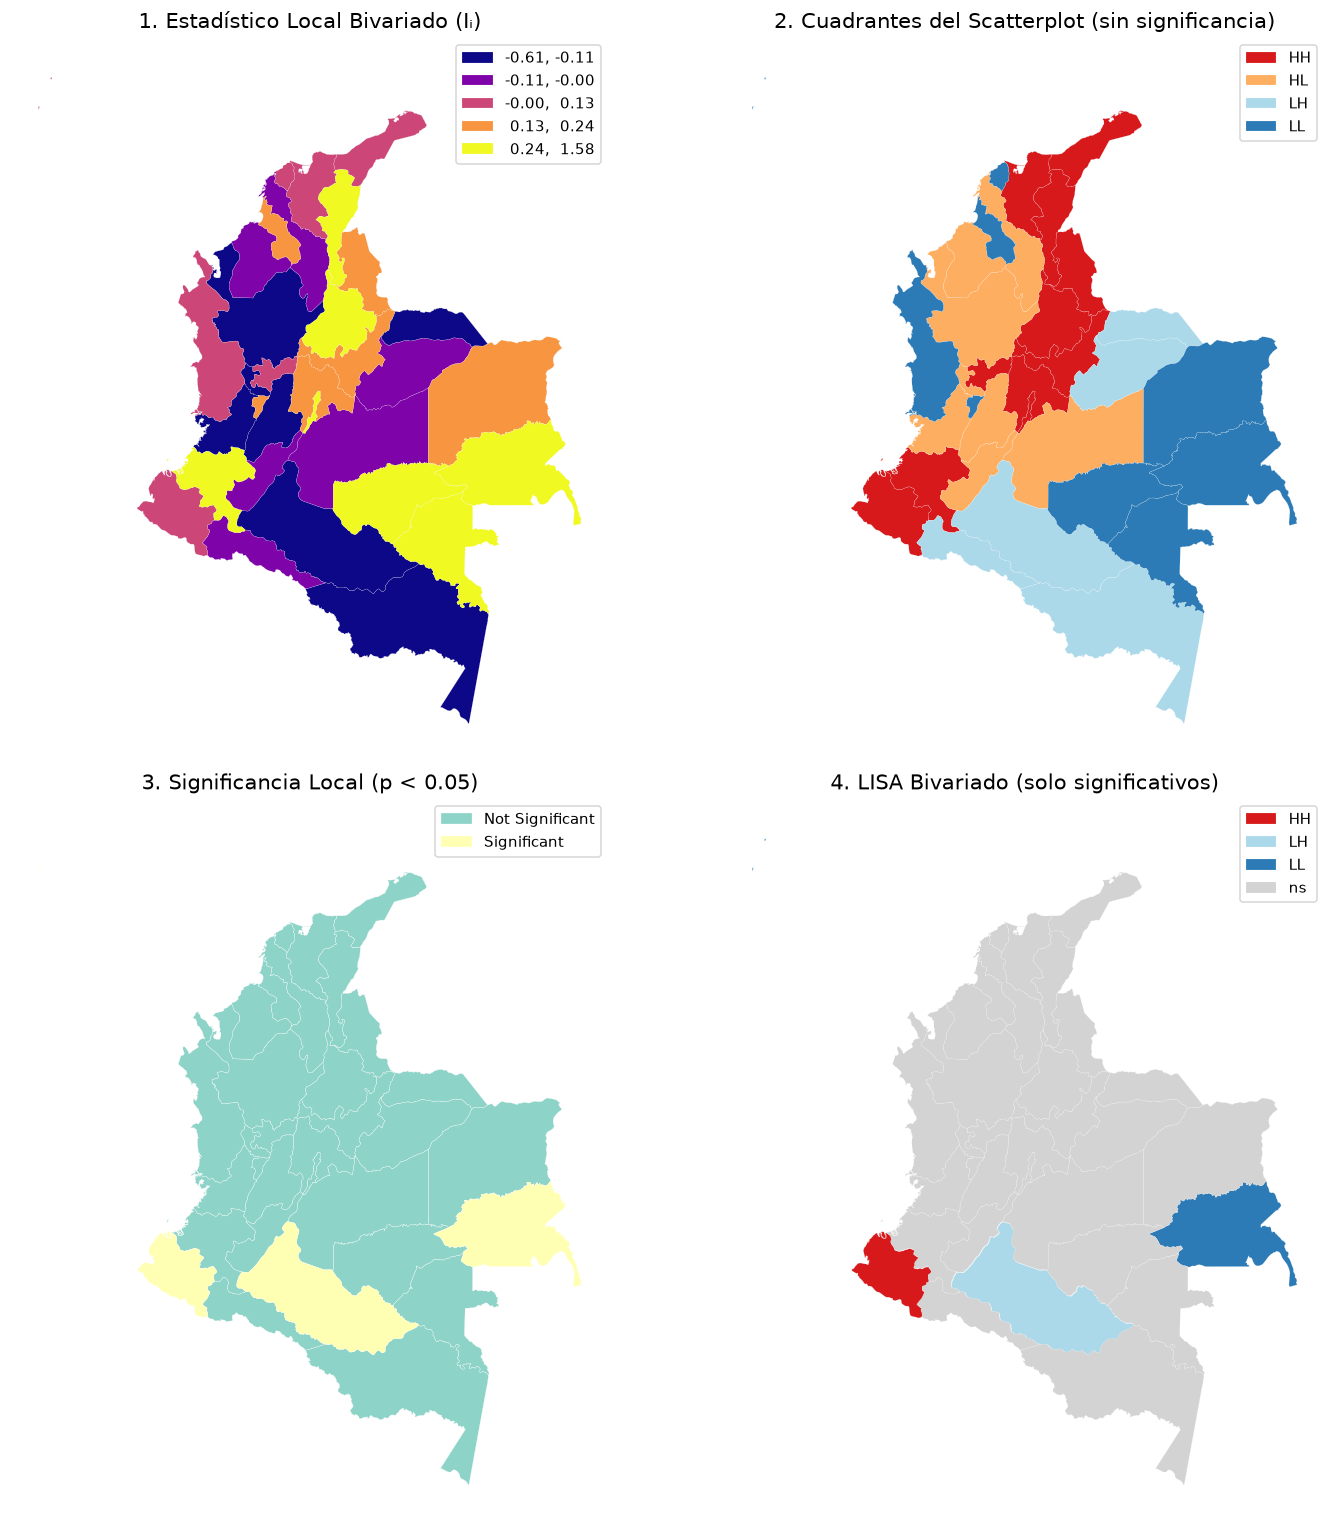

In [164]:
# Crear figura con 4 subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 14))
axs = axs.flatten()

# 1. Mapa del estadístico local bivariado (I_bv)
deptos.plot(
    column="I_bv",
    cmap="plasma",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.1,
    legend=True,
    ax=axs[0]
)
axs[0].set_title("1. Estadístico Local Bivariado (Iᵢ)", fontsize=14)
axs[0].axis("off")

# 2. Mapa de cuadrantes (sin evaluar significancia)
lisa_cluster(ml_bv, deptos, p=1, ax=axs[1])  # p=1 → todos los quadrantes
axs[1].set_title("2. Cuadrantes del Scatterplot (sin significancia)", fontsize=14)
axs[1].axis("off")

# 3. Mapa de significancia local (p < 0.05)
deptos["sig_bv"] = (deptos["p_bv"] < 0.05).map({
    True: "Significant", False: "Not Significant"
})

deptos.plot(
    column="sig_bv",
    categorical=True,
    cmap="Set3",
    k=2,
    legend=True,
    edgecolor="white",
    linewidth=0.2,
    ax=axs[2]
)
axs[2].set_title("3. Significancia Local (p < 0.05)", fontsize=14)
axs[2].axis("off")

# 4. Mapa LISA Bivariado (solo clústeres significativos)
lisa_cluster(ml_bv, deptos, p=0.05, ax=axs[3])
axs[3].set_title("4. LISA Bivariado (solo significativos)", fontsize=14)
axs[3].axis("off")

# Ajustar espacios
plt.tight_layout()
plt.show()